# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

**Jaya Jaya Institut — Sistem Deteksi Dini Mahasiswa Berisiko Dropout**

Jaya Jaya Institut adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000 dan telah
mencetak banyak lulusan dengan reputasi sangat baik. Di balik itu, institut menghadapi masalah
serius: **banyak mahasiswa tidak menyelesaikan pendidikannya alias dropout**. Notebook ini
menjalankan seluruh tahapan proyek data science — dari *business understanding* sampai
*deployment* — untuk membantu institut mendeteksi mahasiswa berisiko dropout sedini mungkin
sehingga dapat diberi bimbingan khusus.

- Nama: Nafiul Irsad
- Email: nafiulirsad@gmail.com
- Id Dicoding: nafiulirsad

## Business Understanding

Jaya Jaya Institut telah berdiri sejak tahun 2000 dan dikenal dengan reputasi lulusan yang sangat
baik. Meski demikian, pihak institut menyadari bahwa **jumlah mahasiswa yang berhenti kuliah
sebelum menyelesaikan studinya (dropout) tergolong tinggi**. Bagi sebuah institusi pendidikan,
tingginya angka dropout adalah masalah besar: ia menggerus rasio kelulusan, menghilangkan
pendapatan dari sisa masa studi mahasiswa, dan dalam jangka panjang menurunkan reputasi akademik
yang selama ini dijaga.

Persoalan utamanya adalah **institut baru mengetahui seorang mahasiswa dropout setelah kejadiannya
berlangsung**. Padahal jejak masalahnya — tunggakan pembayaran, mata kuliah yang tidak lulus,
nilai semester yang jatuh — umumnya sudah terlihat jauh sebelum mahasiswa benar-benar berhenti
kuliah. Tanpa alat bantu, pihak akademik tidak dapat mengetahui mahasiswa mana yang sedang
menuju dropout, dan bimbingan khusus selalu diberikan terlambat.

Karena itu manajemen meminta dua hal: **mendeteksi secepat mungkin mahasiswa yang berpotensi
dropout** agar dapat diberi bimbingan khusus, dan **membuat dashboard** yang memudahkan mereka
memahami data serta memonitor performa mahasiswa secara berkelanjutan.

### Permasalahan Bisnis

1. **Angka dropout tinggi** dan menjadi ancaman langsung bagi target kelulusan, pendapatan, serta
   reputasi institut.
2. **Faktor pendorong dropout belum diketahui secara terukur.** Manajemen belum memiliki bukti
   kuantitatif mengenai variabel apa yang paling menentukan dan segmen mahasiswa mana yang
   paling rentan.
3. **Belum ada mekanisme deteksi dini.** Tidak ada sistem yang menandai mahasiswa berisiko
   sebelum mereka berhenti kuliah, sehingga intervensi selalu terlambat.
4. **Tidak ada alat monitoring.** Data mahasiswa masih berupa berkas mentah sehingga bagian
   akademik tidak dapat memantau performa per program studi, jalur masuk, atau kondisi keuangan.
5. **Mahasiswa yang masih aktif kuliah belum terpantau kondisinya.** Institut tidak mengetahui
   siapa di antara mereka yang perlu diintervensi pada semester berjalan.

### Cakupan Proyek

| Tahap | Keluaran |
|---|---|
| Data Understanding | Profil kualitas data, kamus data, pemeriksaan nilai kosong & duplikat, sebaran status mahasiswa |
| Exploratory Data Analysis | Dropout rate per segmen akademik, keuangan, demografi, program studi, dan jalur masuk (10 visualisasi) |
| Data Preparation | Penyaringan data berlabel (Dropout & Graduate), pembentukan target biner, 9 fitur turunan, pemisahan data mahasiswa aktif |
| Modeling | Perbandingan 3 algoritma + hyperparameter tuning `RandomizedSearchCV` (40 kombinasi × 5-fold) |
| Evaluation | ROC-AUC, PR-AUC, recall, F1/F2, pemilihan ambang operasional, permutation importance, kalibrasi band risiko |
| Deployment | Model `.joblib`, prototipe **Streamlit** (Streamlit Community Cloud), **business dashboard Metabase** di atas PostgreSQL via Docker |

### Tujuan Proyek

1. Mengidentifikasi faktor-faktor yang paling menentukan mahasiswa dropout.
2. Membangun model machine learning yang memprediksi apakah seorang mahasiswa akan **dropout**
   atau **lulus (graduate)**, dengan **recall tinggi** — lebih baik menandai mahasiswa yang
   ternyata aman daripada melewatkan yang benar-benar berisiko.
3. Menyediakan **business dashboard** untuk memonitor performa mahasiswa secara berkelanjutan.
4. Menyediakan **prototipe aplikasi** yang bisa langsung dipakai staf akademik tanpa menulis kode.

## Persiapan

### Menyiapkan library yang dibutuhkan

Seluruh analisis memakai *stack* Python standar untuk data science. Modul lokal
`preprocessing.py` menyimpan kamus label, fungsi *feature engineering*, dan definisi fitur
model — modul yang sama dipakai oleh aplikasi Streamlit sehingga transformasi saat pelatihan
dan saat inferensi dijamin identik (mencegah *training-serving skew*).

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report, confusion_matrix,
    f1_score, fbeta_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import loguniform, randint, uniform

sys.path.append(str(Path.cwd()))
import preprocessing as pp

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Palet warna konsisten untuk seluruh visualisasi:
#   merah-oranye  -> metrik dropout (hal yang ingin ditekan)
#   biru          -> metrik netral / pembanding
#   hijau         -> kondisi aman
DROPOUT = "#E4572E"
NEUTRAL = "#2E86AB"
SAFE = "#2E9E5B"
ACCENT = "#F2A541"
GREY = "#8A939B"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#CCCCCC", "grid.color": "#EAEAEA", "font.size": 10,
})

ASSETS = Path("assets"); ASSETS.mkdir(exist_ok=True)
MODEL_DIR = Path("model"); MODEL_DIR.mkdir(exist_ok=True)
DATA_DIR = Path("data")

print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

pandas 3.0.5 | numpy 2.5.2
scikit-learn 1.9.0


### Menyiapkan data yang akan digunakan

Sumber data: **[Students' Performance — Dicoding Academy](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/README.md)**
(turunan dari *Predict Students' Dropout and Academic Success*, UCI Machine Learning Repository).
Berkas mentah memakai pemisah titik koma (`;`) dan sudah disalin ke `data/data.csv` agar
notebook dapat dijalankan ulang tanpa koneksi internet.

In [2]:
df = pd.read_csv(DATA_DIR / "data.csv", sep=";")

print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]:,}")
df.head()

Jumlah baris  : 4,424
Jumlah kolom  : 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Penjelasan tahapan.** Data berhasil dimuat: **4.424 baris × 37 kolom**. Satu baris mewakili
satu mahasiswa pada saat pendaftaran ditambah rekam jejak akademik dua semester pertama, dan
kolom `Status` berisi hasil akhir studi mahasiswa tersebut.

## Data Understanding

Tahap ini menjawab tiga pertanyaan: *apa isi datanya*, *seberapa bersih datanya*, dan
*bagaimana sebaran targetnya*.

In [3]:
print("=== Tipe data & jumlah nilai non-null ===")
df.info()

print("\n=== Pemeriksaan kualitas data ===")
print(f"Total nilai kosong (missing) : {df.isna().sum().sum()}")
print(f"Baris duplikat               : {df.duplicated().sum()}")
print(f"Kolom konstan (1 nilai unik) : {[c for c in df.columns if df[c].nunique() == 1]}")

=== Tipe data & jumlah nilai non-null ===
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification           

**Insight kualitas data.** Dataset dalam kondisi sangat bersih: **tidak ada satu pun nilai
kosong, tidak ada baris duplikat, dan tidak ada kolom konstan**. Seluruh 36 fitur bertipe
numerik (`int64`/`float64`) dan hanya kolom target `Status` yang bertipe teks. Perlu dicatat
bahwa tipe numerik di sini **menyesatkan**: kolom seperti `Course`, `Application_mode`, dan
`Marital_status` sebenarnya adalah **kode kategorikal**, bukan besaran yang bisa dijumlahkan.
Kesalahan memperlakukannya sebagai numerik akan membuat model mengasumsikan urutan yang tidak
ada — hal ini ditangani pada tahap Data Preparation dengan *one-hot encoding*.

In [4]:
print("=== Statistik deskriptif fitur numerik utama ===")
kolom_ringkas = [
    "Age_at_enrollment", "Admission_grade", "Previous_qualification_grade",
    "Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_approved", "Curricular_units_2nd_sem_grade",
    "Unemployment_rate", "Inflation_rate", "GDP",
]
df[kolom_ringkas].describe().T.round(2)

=== Statistik deskriptif fitur numerik utama ===


,count,mean,std,min,25%,50%,75%,max
Age_at_enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Admission_grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Curricular_units_1st_sem_enrolled,4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular_units_1st_sem_approved,4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular_units_1st_sem_grade,4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular_units_2nd_sem_enrolled,4424.0,6.23,2.20,0.00,5.00,6.00,7.00,23.00
Curricular_units_2nd_sem_approved,4424.0,4.44,3.01,0.00,2.00,5.00,6.00,20.00
Curricular_units_2nd_sem_grade,4424.0,10.23,5.21,0.00,10.75,12.20,13.33,18.57
Unemployment_rate,4424.0,11.57,2.66,7.60,9.40,11.10,13.90,16.20


**Insight statistik deskriptif.** Usia saat mendaftar berkisar 17-70 tahun dengan median 20
tahun — artinya ada kelompok mahasiswa non-tradisional (usia lanjut) yang perlu diperiksa
terpisah. Nilai masuk (`Admission_grade`) memakai skala 0-200 dengan rata-rata ± 127.
Yang paling penting: **nilai semester (`..._sem_grade`) memiliki nilai minimum 0**, dan angka 0
di sini bukan berarti "nilai jelek" melainkan **mahasiswa tidak menempuh evaluasi sama sekali** —
sinyal keterlibatan (*engagement*) yang sangat kuat dan akan dipakai sebagai fitur turunan.

### Kamus data

Ke-37 kolom dapat dikelompokkan menjadi kelompok berikut.

| Kelompok | Kolom | Keterangan |
|---|---|---|
| **Demografi** | `Marital_status`, `Gender`, `Age_at_enrollment`, `Nacionality`, `International`, `Displaced`, `Educational_special_needs` | Profil pribadi mahasiswa. Kolom berkode: 1 = laki-laki / 0 = perempuan pada `Gender`. |
| **Latar belakang keluarga** | `Mothers_qualification`, `Fathers_qualification`, `Mothers_occupation`, `Fathers_occupation` | Kode pendidikan & pekerjaan orang tua. |
| **Pendaftaran** | `Application_mode`, `Application_order`, `Course`, `Daytime_evening_attendance`, `Previous_qualification`, `Previous_qualification_grade`, `Admission_grade` | Jalur masuk, program studi, dan nilai seleksi. |
| **Keuangan** | `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder` | Status tunggakan, kelunasan pembayaran, dan beasiswa. |
| **Akademik semester 1 & 2** | `Curricular_units_{1st,2nd}_sem_{credited,enrolled,evaluations,approved,grade,without_evaluations}` | Jumlah mata kuliah diambil, dievaluasi, lulus, serta nilai rata-rata per semester. |
| **Makroekonomi** | `Unemployment_rate`, `Inflation_rate`, `GDP` | Kondisi ekonomi pada tahun angkatan. |
| **Target** | `Status` | `Dropout`, `Enrolled` (masih aktif kuliah), atau `Graduate` (lulus). |

          Jumlah  Persentase (%)
Status                          
Graduate    2209           49.93
Dropout     1421           32.12
Enrolled     794           17.95


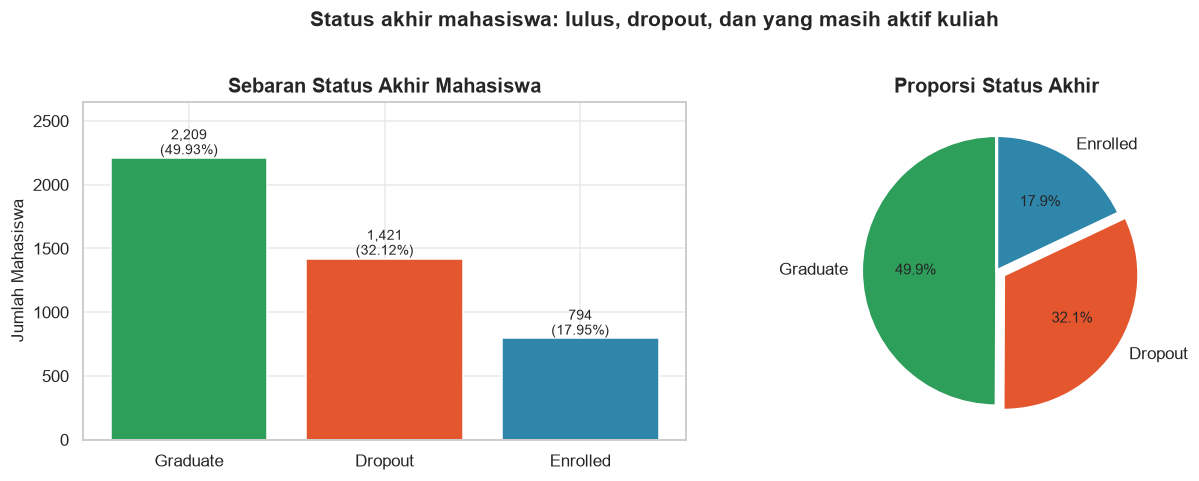

In [5]:
status_count = df["Status"].value_counts()
status_pct = (status_count / len(df) * 100).round(2)
ringkasan_status = pd.DataFrame({"Jumlah": status_count, "Persentase (%)": status_pct})
print(ringkasan_status.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
warna = {"Graduate": SAFE, "Dropout": DROPOUT, "Enrolled": NEUTRAL}
urut = ["Graduate", "Dropout", "Enrolled"]

bars = axes[0].bar(urut, [status_count[s] for s in urut], color=[warna[s] for s in urut])
for b, s in zip(bars, urut):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 30,
                 f"{status_count[s]:,}\n({status_pct[s]}%)", ha="center", fontsize=9)
axes[0].set_title("Sebaran Status Akhir Mahasiswa")
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].set_ylim(0, status_count.max() * 1.2)

axes[1].pie([status_count[s] for s in urut], labels=urut, colors=[warna[s] for s in urut],
            autopct="%1.1f%%", startangle=90, explode=(0, 0.06, 0),
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporsi Status Akhir")

fig.suptitle("Status akhir mahasiswa: lulus, dropout, dan yang masih aktif kuliah",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(ASSETS / "01_sebaran_status.png")
plt.show()

**Insight sebaran target.** Dari 4.424 mahasiswa: **2.209 lulus (49,93%), 1.421 dropout
(32,12%), dan 794 masih aktif kuliah (17,95%)**.

Kelompok **Enrolled** perlu diperlakukan berbeda. Status mereka **belum final** — mereka belum
lulus, tetapi juga belum dropout — sehingga label mereka tidak diketahui. Memasukkan mereka ke
dalam data latih sebagai "bukan dropout" berarti memberi model label yang belum tentu benar.
Karena itu, pada tahap Data Preparation nanti data akan **disaring hanya untuk status Dropout dan
Graduate** (2 kelas yang hasil akhirnya sudah pasti), sedangkan **794 mahasiswa Enrolled disimpan
terpisah** dan hanya dipakai sebagai sasaran prediksi di masa mendatang.

Dengan penyaringan tersebut, data pemodelan berisi **3.630 mahasiswa: 1.421 dropout (39,15%)
berbanding 2.209 lulus (60,85%)**. Proporsi ini **cukup seimbang** untuk klasifikasi biner —
tidak ideal 50:50, tetapi masih jauh dari kondisi ekstrem — sehingga model dapat belajar dari
kedua kelas dengan baik. Meskipun begitu, akurasi tetap bukan metrik yang tepat (model yang
selalu menebak "lulus" sudah mendapat akurasi 60,85% tanpa berguna), sehingga evaluasi memakai
**ROC-AUC, PR-AUC, dan recall**, dibantu `class_weight="balanced"` saat pelatihan.

### Exploratory Data Analysis

Pertanyaan yang dijawab pada tahap ini: **segmen mahasiswa mana yang dropout-nya di atas
rata-rata?**

Analisis dilakukan pada **3.630 mahasiswa yang status akhirnya sudah pasti (Dropout atau
Graduate)**. Mahasiswa berstatus `Enrolled` dikeluarkan dari perhitungan dropout rate karena
hasil akhir mereka belum diketahui — memasukkan mereka sebagai "bukan dropout" akan menekan
angka secara keliru. Dengan basis tersebut, **dropout rate rujukan adalah 39,15%**, dan setiap
grafik memakai garis pembanding putus-putus pada angka itu sehingga pembaca langsung dapat
menilai segmen mana yang bermasalah, bukan sekadar melihat tinggi-rendahnya batang.

Kode-kode numerik diterjemahkan menjadi label yang terbaca lewat modul `preprocessing.py`.

In [6]:
# Seluruh data (3 status) untuk perbandingan antar kelompok
full = pp.add_readable_labels(pp.engineer_features(df))

# Kohort berlabel: hanya mahasiswa yang status akhirnya sudah pasti
eda = full[full["Status"].isin(["Dropout", "Graduate"])].copy()
eda["is_dropout"] = (eda["Status"] == pp.POSITIVE_CLASS).astype(int)

BASELINE = eda["is_dropout"].mean() * 100
print(f"Kohort berlabel        : {len(eda):,} mahasiswa "
      f"({int(eda['is_dropout'].sum()):,} dropout / {int((1 - eda['is_dropout']).sum()):,} lulus)")
print(f"Dropout rate rujukan   : {BASELINE:.2f}%")
print(f"Mahasiswa aktif (Enrolled) yang dipisahkan: {int((full['Status'] == 'Enrolled').sum()):,}")

def dropout_rate(kolom, urutan=None, min_n=1):
    """Hitung dropout rate (%) dan jumlah mahasiswa untuk setiap kategori pada `kolom`."""
    g = eda.groupby(kolom, observed=True)["is_dropout"].agg(jumlah="size", rate="mean")
    g["rate"] = g["rate"] * 100
    g = g[g["jumlah"] >= min_n]
    return g.loc[urutan] if urutan else g.sort_values("rate", ascending=False)

def plot_rate(ax, tabel, judul, xlabel="", horizontal=False, warna=DROPOUT):
    """Gambar dropout rate per kategori beserta garis pembanding rata-rata kohort."""
    label = [f"{i}\n(n={int(r.jumlah)})" if not horizontal else f"{i} (n={int(r.jumlah)})"
             for i, r in tabel.iterrows()]
    if horizontal:
        ax.barh(label, tabel["rate"], color=warna)
        ax.axvline(BASELINE, color=GREY, ls="--", lw=1.4)
        ax.set_xlabel("Dropout Rate (%)")
        for y, v in enumerate(tabel["rate"]):
            ax.text(v + 0.8, y, f"{v:.1f}%", va="center", fontsize=9)
        ax.set_xlim(0, max(tabel["rate"]) * 1.18)
        ax.invert_yaxis()
    else:
        ax.bar(label, tabel["rate"], color=warna)
        ax.axhline(BASELINE, color=GREY, ls="--", lw=1.4)
        ax.set_ylabel("Dropout Rate (%)")
        for x, v in enumerate(tabel["rate"]):
            ax.text(x, v + 1.2, f"{v:.1f}%", ha="center", fontsize=9)
        ax.set_ylim(0, max(tabel["rate"]) * 1.22)
    ax.set_title(judul)
    ax.set_xlabel(xlabel) if not horizontal else None
    ax.grid(axis="x" if horizontal else "y", alpha=.4)
    ax.grid(axis="y" if horizontal else "x", visible=False)

Kohort berlabel        : 3,630 mahasiswa (1,421 dropout / 2,209 lulus)
Dropout rate rujukan   : 39.15%
Mahasiswa aktif (Enrolled) yang dipisahkan: 794


#### 1. Faktor keuangan

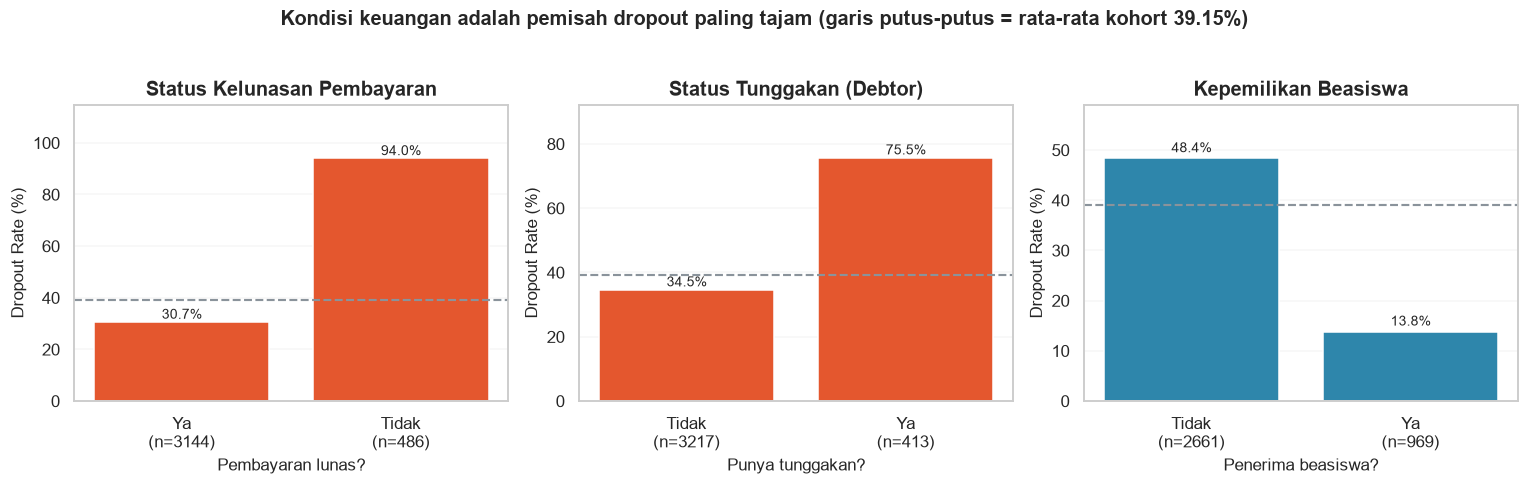

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
plot_rate(axes[0], dropout_rate("tuition_fees_up_to_date_label", ["Ya", "Tidak"]),
          "Status Kelunasan Pembayaran", "Pembayaran lunas?")
plot_rate(axes[1], dropout_rate("debtor_label", ["Tidak", "Ya"]),
          "Status Tunggakan (Debtor)", "Punya tunggakan?")
plot_rate(axes[2], dropout_rate("scholarship_holder_label", ["Tidak", "Ya"]),
          "Kepemilikan Beasiswa", "Penerima beasiswa?", warna=NEUTRAL)
fig.suptitle("Kondisi keuangan adalah pemisah dropout paling tajam "
             f"(garis putus-putus = rata-rata kohort {BASELINE:.2f}%)",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout()
fig.savefig(ASSETS / "02_faktor_keuangan.png")
plt.show()

**Insight faktor keuangan — sinyal paling tajam di seluruh dataset.**

- Mahasiswa yang **pembayarannya belum lunas dropout sebesar 94,03%**, dibanding **30,66%** pada
  yang lunas. Dari 486 mahasiswa yang menunggak pembayaran, 457 di antaranya berakhir dropout —
  praktis hampir semuanya. Inilah prediktor tunggal terkuat pada dataset ini.
- Mahasiswa dengan status **debtor dropout 75,54%** versus 34,47% pada yang tidak menunggak.
- **Beasiswa bekerja sebagai pelindung**: penerima beasiswa hanya dropout **13,83%**, kurang dari
  sepertiga angka non-penerima (48,37%).

Implikasi bisnis langsung: **masalah keuangan lebih menentukan daripada kemampuan akademik**.
Tunggakan pembayaran bukan sekadar urusan administrasi, melainkan alarm dropout yang datanya
sudah dimiliki institut setiap bulan.

#### 2. Faktor demografi dan pola kuliah

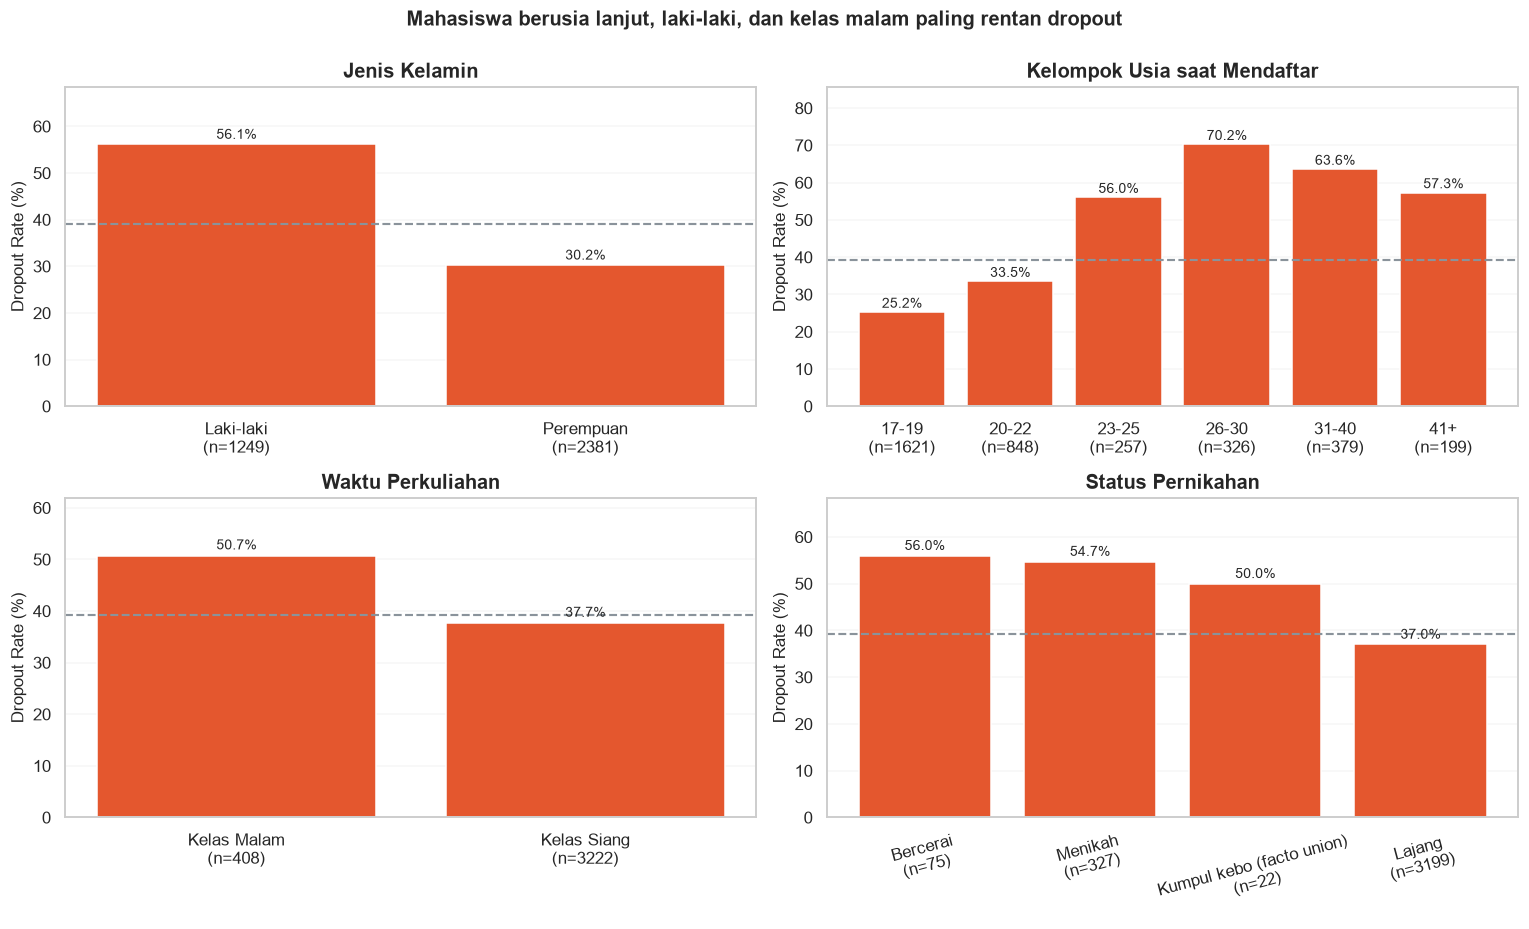

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.4))
plot_rate(axes[0][0], dropout_rate("jenis_kelamin"), "Jenis Kelamin")
plot_rate(axes[0][1], dropout_rate("kelompok_usia", ["17-19", "20-22", "23-25", "26-30", "31-40", "41+"]),
          "Kelompok Usia saat Mendaftar")
plot_rate(axes[1][0], dropout_rate("waktu_kuliah"), "Waktu Perkuliahan")
plot_rate(axes[1][1], dropout_rate("status_pernikahan", min_n=20), "Status Pernikahan")
axes[1][1].tick_params(axis="x", labelrotation=15)
fig.suptitle("Mahasiswa berusia lanjut, laki-laki, dan kelas malam paling rentan dropout",
             fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(ASSETS / "03_faktor_demografi.png")
plt.show()

**Insight faktor demografi.**

- **Usia adalah gradien yang jelas.** Dropout naik dari **25,23% (usia 17-19)** menjadi
  **56,03% (23-25)** dan memuncak pada **70,25% (26-30)**. Mahasiswa yang mendaftar pada usia
  lanjut umumnya sudah bekerja atau berkeluarga sehingga kuliah bersaing dengan kewajiban lain.
- **Laki-laki dropout 56,12%**, hampir dua kali lipat perempuan (**30,24%**).
- **Kelas malam dropout 50,74%** versus kelas siang 37,68% — konsisten dengan temuan usia, karena
  kelas malam banyak diisi mahasiswa yang bekerja.
- **Mahasiswa menikah dropout 54,74%** dan yang bercerai 56,00%, dibanding lajang 37,01%.

Keempat temuan ini mengarah ke satu profil yang sama: **mahasiswa dengan beban hidup di luar
kampus**. Program pendampingan tidak cukup bersifat akademik — perlu fleksibilitas jadwal.

#### 3. Performa akademik dua semester pertama

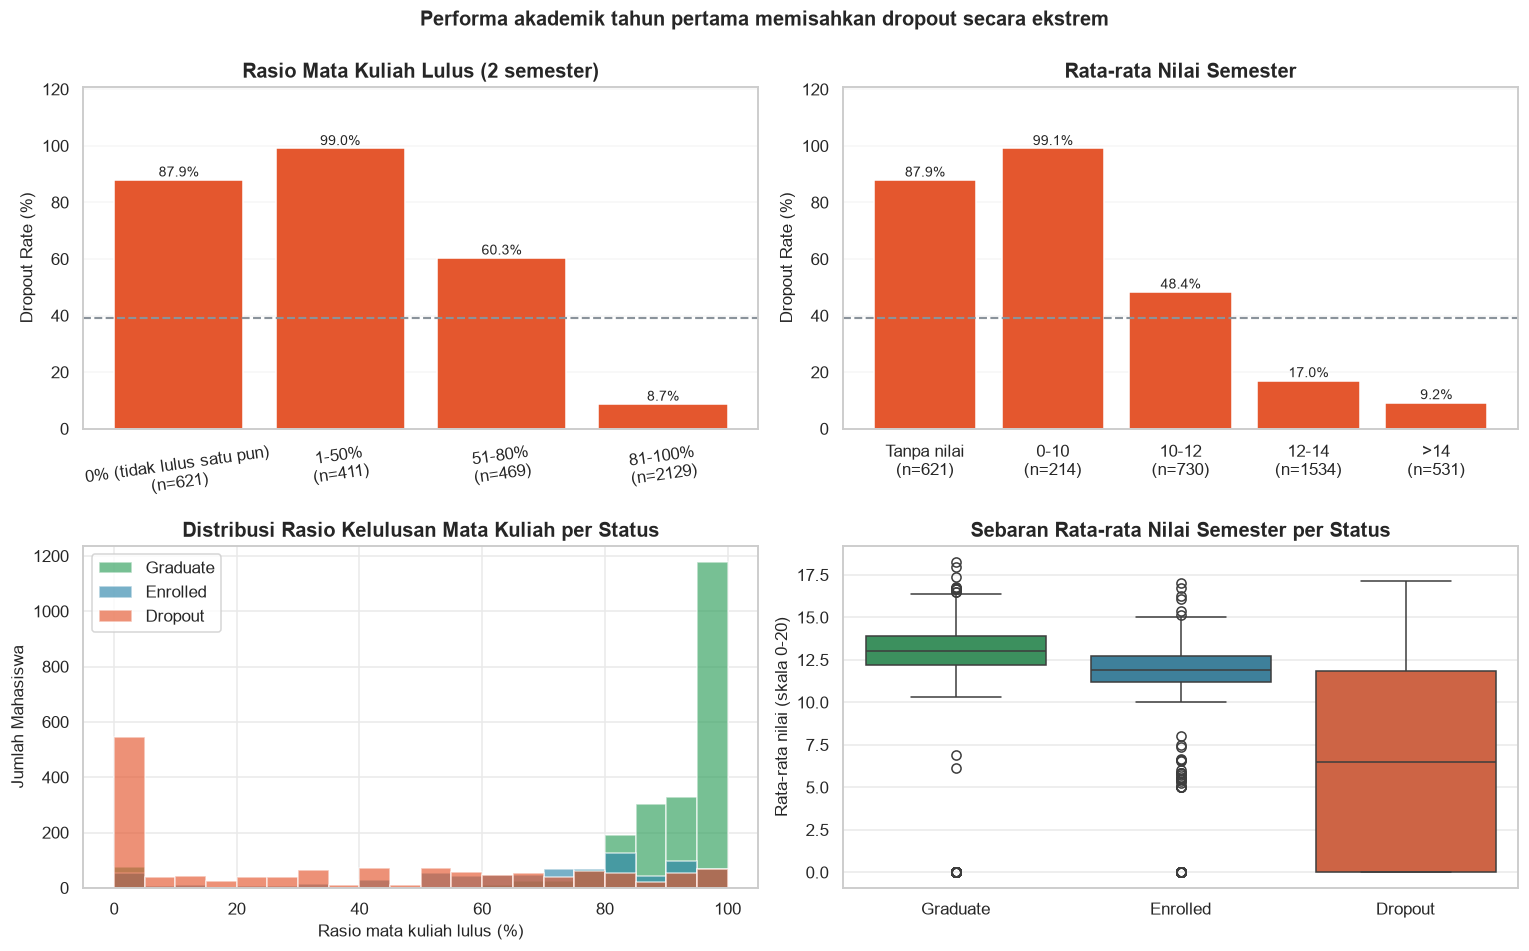

          approval_rate_total  avg_grade  total_approved
Status                                                  
Dropout                 0.339      6.578           4.492
Enrolled                0.669     11.121           8.377
Graduate                0.902     12.670          12.409


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.6))

plot_rate(axes[0][0], dropout_rate("band_kelulusan_sks",
          ["0% (tidak lulus satu pun)", "1-50%", "51-80%", "81-100%"]),
          "Rasio Mata Kuliah Lulus (2 semester)")
axes[0][0].tick_params(axis="x", labelrotation=8)

plot_rate(axes[0][1], dropout_rate("band_nilai_semester",
          ["Tanpa nilai", "0-10", "10-12", "12-14", ">14"]),
          "Rata-rata Nilai Semester")

# Panel bawah memakai seluruh data (3 status) untuk memperlihatkan posisi mahasiswa aktif
for status, warna in [("Graduate", SAFE), ("Enrolled", NEUTRAL), ("Dropout", DROPOUT)]:
    sub = full[full["Status"] == status]
    axes[1][0].hist(sub["approval_rate_total"] * 100, bins=20, alpha=.65, label=status, color=warna)
axes[1][0].set_title("Distribusi Rasio Kelulusan Mata Kuliah per Status")
axes[1][0].set_xlabel("Rasio mata kuliah lulus (%)"); axes[1][0].set_ylabel("Jumlah Mahasiswa")
axes[1][0].legend()

sns.boxplot(data=full, x="Status", y="avg_grade", order=["Graduate", "Enrolled", "Dropout"],
            palette={"Graduate": SAFE, "Enrolled": NEUTRAL, "Dropout": DROPOUT}, ax=axes[1][1])
axes[1][1].set_title("Sebaran Rata-rata Nilai Semester per Status")
axes[1][1].set_ylabel("Rata-rata nilai (skala 0-20)"); axes[1][1].set_xlabel("")

fig.suptitle("Performa akademik tahun pertama memisahkan dropout secara ekstrem",
             fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(ASSETS / "04_performa_akademik.png")
plt.show()

print(full.groupby("Status")[["approval_rate_total", "avg_grade", "total_approved"]]
         .mean().round(3).to_string())

**Insight performa akademik — pemisah terkuat kedua.**

- Mahasiswa yang **hanya lulus 1-50% mata kuliah dropout 99,03%** (411 orang) dan yang **tidak
  lulus satu pun dropout 87,92%** (621 orang), sementara yang lulus 81-100% mata kuliah hanya
  dropout **8,69%** (2.129 orang). Rentangnya lebih dari **11 kali lipat**.
- Menarik bahwa kelompok "tidak lulus satu pun" sedikit lebih rendah daripada kelompok "1-50%".
  Penyebabnya: sebagian mahasiswa pada kelompok 0% memiliki mata kuliah yang diakui
  (*credited*) dari pendidikan sebelumnya sehingga tetap dapat melanjutkan studi hingga lulus.
  Kelompok 1-50% adalah gambaran paling murni dari mahasiswa yang benar-benar mencoba namun gagal.
- Pola yang sama terlihat pada nilai: rata-rata nilai di bawah 10 → dropout **99,07%**;
  di atas 14 → dropout **9,23%**.
- Rata-rata rasio kelulusan mata kuliah pada seluruh data: **Graduate 0,902 — Enrolled 0,669 —
  Dropout 0,339**. Kelompok Enrolled berada persis di tengah, yang menegaskan alasan mereka
  dikeluarkan dari data latih: hasil akhir mereka memang belum dapat disimpulkan.
- Histogram memperlihatkan **penumpukan besar mahasiswa dropout tepat di rasio 0%** — kelompok
  yang mendaftar lalu praktis tidak pernah mengikuti evaluasi. Ini bukan kegagalan akademik
  bertahap, melainkan **putus keterlibatan sejak awal** yang seharusnya terdeteksi pada
  minggu-minggu pertama perkuliahan.

#### 4. Program studi dan jalur masuk

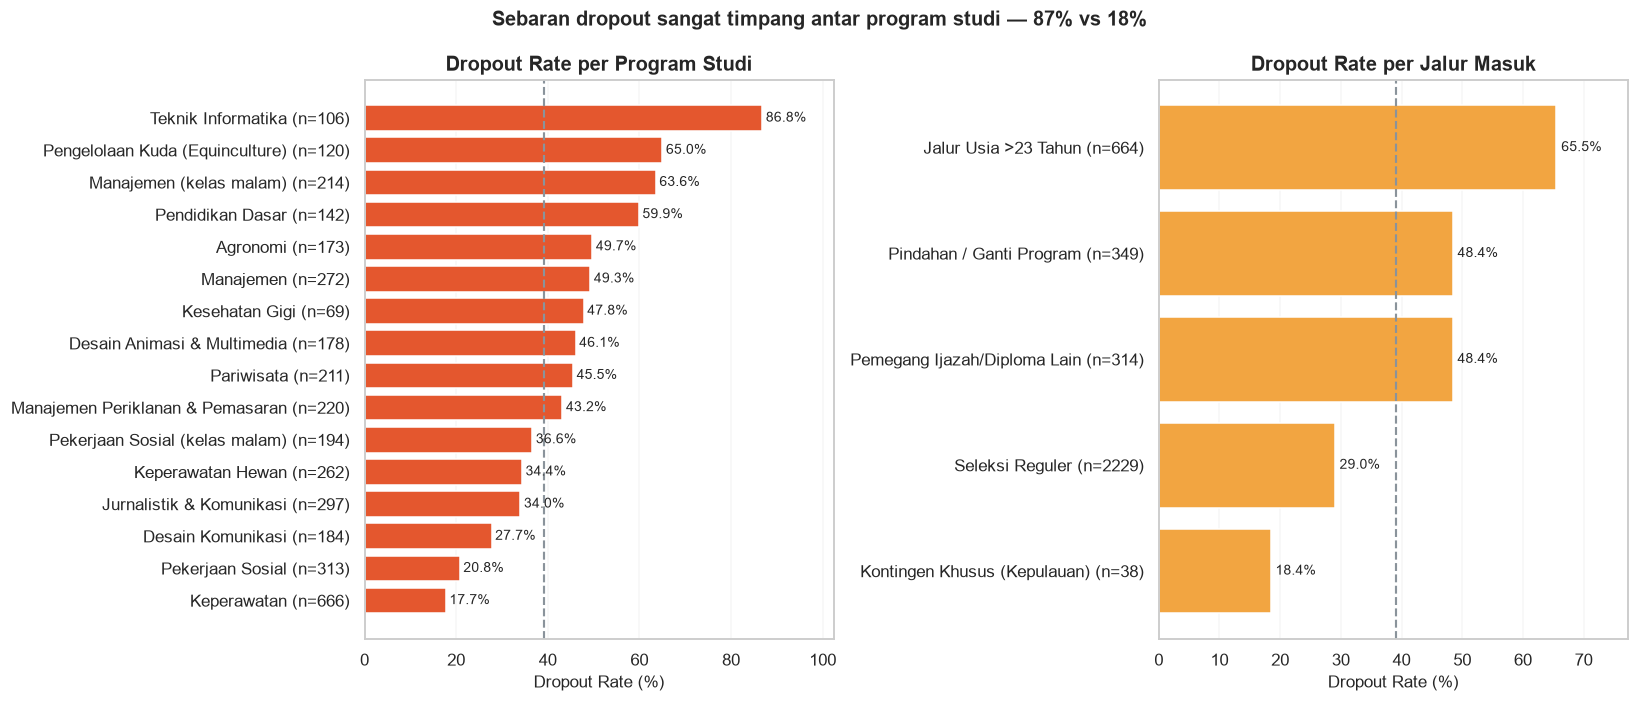

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))
plot_rate(axes[0], dropout_rate("program_studi", min_n=30), "Dropout Rate per Program Studi",
          horizontal=True)
plot_rate(axes[1], dropout_rate("jalur_masuk", min_n=30), "Dropout Rate per Jalur Masuk",
          horizontal=True, warna=ACCENT)
fig.suptitle("Sebaran dropout sangat timpang antar program studi — 87% vs 18%",
             fontsize=13, fontweight="bold", y=0.99)
fig.tight_layout()
fig.savefig(ASSETS / "05_program_studi.png")
plt.show()

**Insight program studi & jalur masuk.**

- Selisih antar program studi sangat lebar: **Teknik Informatika (86,79%)**, **Pengelolaan Kuda
  (65,00%)**, dan **Manajemen kelas malam (63,55%)** berada di ujung atas, sedangkan
  **Keperawatan hanya 17,72%** dengan populasi terbesar (666 mahasiswa) dan **Pekerjaan Sosial
  20,77%**. Artinya masalah dropout **tidak merata** dan intervensi paling efisien bila
  difokuskan pada 4-5 program studi teratas.
- Dari sisi jalur masuk, **jalur usia di atas 23 tahun dropout 65,51%** (664 mahasiswa),
  **pindahan/ganti program 48,42%**, dan **pemegang ijazah/diploma lain 48,41%**, sementara
  **seleksi reguler hanya 28,98%** (2.229 mahasiswa). Jalur non-reguler menyumbang risiko yang
  jauh lebih besar dan layak diberi program orientasi khusus sejak awal semester.

#### 5. Korelasi fitur numerik terhadap dropout

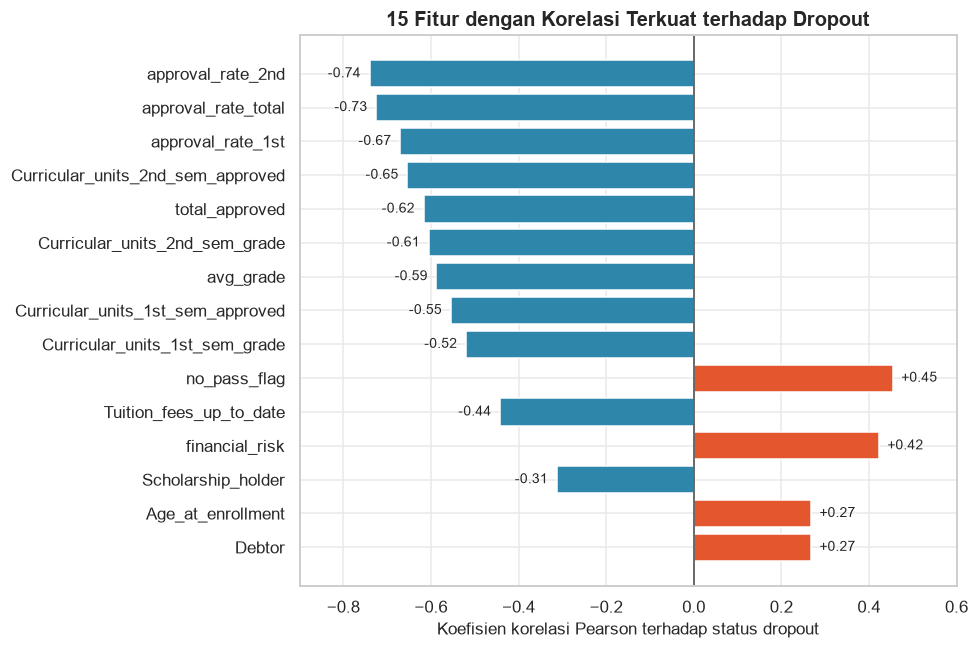

approval_rate_2nd                   -0.740
approval_rate_total                 -0.725
approval_rate_1st                   -0.670
Curricular_units_2nd_sem_approved   -0.654
total_approved                      -0.617
Curricular_units_2nd_sem_grade      -0.605
avg_grade                           -0.587
Curricular_units_1st_sem_approved   -0.555
Curricular_units_1st_sem_grade      -0.520
no_pass_flag                         0.454
Tuition_fees_up_to_date             -0.442
financial_risk                       0.422
Scholarship_holder                  -0.313
Age_at_enrollment                    0.267
Debtor                               0.267


In [11]:
num_cols = eda.select_dtypes(include=[np.number]).columns
korelasi = (eda[num_cols].corr(numeric_only=True)["is_dropout"]
            .drop("is_dropout").sort_values(key=abs, ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
warna_bar = [DROPOUT if v > 0 else NEUTRAL for v in korelasi]
ax.barh(korelasi.index[::-1], korelasi.values[::-1], color=warna_bar[::-1])
ax.axvline(0, color="#444444", lw=1)
for y, v in enumerate(korelasi.values[::-1]):
    ax.text(v + (0.02 if v > 0 else -0.02), y, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9)
ax.set_title("15 Fitur dengan Korelasi Terkuat terhadap Dropout")
ax.set_xlabel("Koefisien korelasi Pearson terhadap status dropout")
ax.set_xlim(-0.9, 0.6)
fig.tight_layout()
fig.savefig(ASSETS / "06_korelasi.png")
plt.show()

print(korelasi.round(3).to_string())

**Insight korelasi.** Peringkat korelasi mengonfirmasi seluruh temuan visual sebelumnya:

| Peringkat | Fitur | Korelasi |
|---|---|---|
| 1 | `approval_rate_2nd` (rasio lulus semester 2) | **-0,74** |
| 2 | `approval_rate_total` | -0,73 |
| 3 | `approval_rate_1st` | -0,67 |
| 4 | `Curricular_units_2nd_sem_approved` | -0,65 |
| 5 | `total_approved` | -0,62 |
| 6 | `Curricular_units_2nd_sem_grade` | -0,61 |
| 7 | `no_pass_flag` | **+0,45** |
| 8 | `Tuition_fees_up_to_date` | -0,44 |
| 9 | `financial_risk` | +0,42 |

Tiga hal penting. Pertama, **semester kedua lebih informatif daripada semester pertama**
(-0,74 vs -0,67) sehingga akhir tahun pertama adalah titik prediksi paling akurat. Kedua,
**fitur turunan hasil rekayasa (`approval_rate_*`, `no_pass_flag`, `financial_risk`) mengungguli
fitur mentahnya**, yang membenarkan langkah feature engineering. Ketiga, **faktor makroekonomi
(`Unemployment_rate`, `Inflation_rate`, `GDP`) tidak masuk 15 besar** — kondisi ekonomi nasional
hampir tidak menjelaskan variasi dropout antar mahasiswa dalam data ini.

## Data Preparation / Preprocessing

Lima keputusan diambil pada tahap ini, masing-masing dengan alasan yang eksplisit.

**1. Data disaring hanya untuk mahasiswa berstatus `Dropout` dan `Graduate`.**
Tujuan model adalah memprediksi apakah seorang mahasiswa akan **dropout** atau **lulus**.
Mahasiswa berstatus `Enrolled` **belum memiliki hasil akhir** — mereka belum lulus, tetapi juga
belum dropout. Melibatkan mereka dalam pelatihan berarti memberi model label yang belum tentu
benar dan merusak validitas prediksi. Karena itu 794 mahasiswa `Enrolled` **dikeluarkan dari data
latih dan disimpan terpisah**, untuk dipakai sebagai sasaran prediksi di masa mendatang.

**2. Target biner dibentuk: 1 = Dropout, 0 = Graduate.** Setelah penyaringan, distribusi target
diverifikasi untuk memastikan kedua kelas cukup berimbang sehingga model dapat belajar dari
keduanya.

**3. Feature engineering menambah 9 fitur turunan.** Jumlah mata kuliah lulus saja tidak
bermakna tanpa tahu berapa yang diambil; yang informatif adalah **rasionya**. Fitur turunan
yang dibuat: `approval_rate_1st`, `approval_rate_2nd`, `approval_rate_total`, `total_approved`,
`avg_grade`, `grade_trend` (selisih nilai semester 2 - 1), `approval_trend`, `financial_risk`
(gabungan tunggakan + pembayaran belum lunas), dan `no_pass_flag`.

**4. Fitur dipangkas dari 36 menjadi 29 kolom yang mudah diperoleh.** Kolom pendidikan/pekerjaan
orang tua, kewarganegaraan, dan indikator makroekonomi dibuang karena (a) korelasinya rendah,
(b) sulit dan lambat dikumpulkan staf akademik saat memakai aplikasi. Uji banding menunjukkan
pemangkasan ini **tidak menurunkan performa secara berarti**, sementara formulir aplikasi
menjadi jauh lebih ringkas.

**5. Kode kategorikal di-*one-hot encode*.** `Marital_status`, `Application_mode`, dan `Course`
adalah kode, bukan angka berurutan. Kategori dengan frekuensi di bawah 20 digabung otomatis
(`min_frequency=20`) agar model tidak menghafal kategori langka.

In [12]:
# --- 1. Feature engineering pada seluruh data --------------------------------------------
data = pp.engineer_features(df)

# --- 2. Pisahkan mahasiswa yang masih aktif kuliah ---------------------------------------
# Status Enrolled belum final -> tidak dipakai melatih model, hanya untuk prediksi ke depan.
enrolled = data[data[pp.TARGET_COLUMN] == "Enrolled"].copy()
labeled = data[data[pp.TARGET_COLUMN].isin(["Dropout", "Graduate"])].copy()

print(f"Data mentah                    : {len(data):,} mahasiswa")
print(f"Dikeluarkan (status Enrolled)  : {len(enrolled):,} mahasiswa -> disimpan terpisah")
print(f"Dipakai untuk pemodelan        : {len(labeled):,} mahasiswa")

# --- 3. Bentuk target biner: 1 = Dropout, 0 = Graduate -----------------------------------
labeled["target"] = (labeled[pp.TARGET_COLUMN] == pp.POSITIVE_CLASS).astype(int)

# --- 4. Verifikasi distribusi target -----------------------------------------------------
distribusi = labeled["target"].value_counts().sort_index()
distribusi.index = ["0 = Graduate", "1 = Dropout"]
verifikasi = pd.DataFrame({
    "Jumlah": distribusi,
    "Proporsi (%)": (distribusi / len(labeled) * 100).round(2),
})
print("\n=== Verifikasi distribusi target ===")
print(verifikasi.to_string())
rasio = distribusi.max() / distribusi.min()
print(f"\nRasio kelas mayoritas : minoritas = {rasio:.2f} : 1")
print("Status keseimbangan  :",
      "seimbang (rasio < 1,5:1)" if rasio < 1.5 else
      "cukup seimbang (rasio < 3:1)" if rasio < 3 else "tidak seimbang (perlu penanganan khusus)")

y = labeled["target"]
X = labeled[pp.MODEL_FEATURES]
print(f"\nDimensi matriks fitur : {X.shape}")
print(f"Fitur kategorikal ({len(pp.CATEGORICAL_FEATURES)}): {pp.CATEGORICAL_FEATURES}")
print(f"Fitur numerik ({len(pp.NUMERIC_FEATURES)}):")
print("   " + ", ".join(pp.NUMERIC_FEATURES))

Data mentah                    : 4,424 mahasiswa
Dikeluarkan (status Enrolled)  : 794 mahasiswa -> disimpan terpisah
Dipakai untuk pemodelan        : 3,630 mahasiswa

=== Verifikasi distribusi target ===
              Jumlah  Proporsi (%)
0 = Graduate    2209         60.85
1 = Dropout     1421         39.15

Rasio kelas mayoritas : minoritas = 1.55 : 1
Status keseimbangan  : cukup seimbang (rasio < 3:1)

Dimensi matriks fitur : (3630, 29)
Fitur kategorikal (3): ['Marital_status', 'Application_mode', 'Course']
Fitur numerik (26):
   Application_order, Daytime_evening_attendance, Previous_qualification_grade, Admission_grade, Displaced, Debtor, Tuition_fees_up_to_date, Gender, Scholarship_holder, Age_at_enrollment, International, Curricular_units_1st_sem_enrolled, Curricular_units_1st_sem_approved, Curricular_units_1st_sem_grade, Curricular_units_2nd_sem_enrolled, Curricular_units_2nd_sem_approved, Curricular_units_2nd_sem_grade, approval_rate_1st, approval_rate_2nd, approval_rate_total,

**Insight verifikasi distribusi target.** Setelah penyaringan, data pemodelan berisi
**3.630 mahasiswa: 1.421 dropout (39,15%) dan 2.209 lulus (60,85%)** — rasio **1,55 : 1**.
Proporsi ini tergolong **cukup seimbang**: keduanya jauh dari kondisi kelas langka (di bawah 10%)
sehingga model dapat mempelajari pola kedua kelas tanpa memerlukan teknik *oversampling* seperti
SMOTE. Meski begitu, kelas dropout tetap minoritas, sehingga pelatihan tetap memakai
`class_weight="balanced"` dan evaluasi bertumpu pada ROC-AUC, PR-AUC, serta recall — bukan
akurasi.

794 mahasiswa `Enrolled` sudah dipisahkan dan akan diberi skor risiko pada tahap Deployment
sebagai **prediksi ke depan**, bukan sebagai bahan pelatihan.

In [13]:
# --- 5. Pembagian data latih & uji -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Data latih : {X_train.shape[0]:,} baris ({y_train.mean()*100:.2f}% dropout)")
print(f"Data uji   : {X_test.shape[0]:,} baris ({y_test.mean()*100:.2f}% dropout)")

# --- 6. Pipeline preprocessing -----------------------------------------------------------
def buat_preprocessor(scale: bool):
    """One-hot untuk kode kategorikal; penskalaan hanya diperlukan model linier."""
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False),
         pp.CATEGORICAL_FEATURES),
        ("num", StandardScaler() if scale else "passthrough", pp.NUMERIC_FEATURES),
    ])

contoh = buat_preprocessor(False).fit(X_train)
print(f"\nJumlah kolom setelah encoding: {contoh.transform(X_train).shape[1]}")

Data latih : 2,904 baris (39.15% dropout)
Data uji   : 726 baris (39.12% dropout)

Jumlah kolom setelah encoding: 59


**Penjelasan tahapan.** Data dibagi **80% latih (2.904 baris) / 20% uji (726 baris)** dengan
`stratify=y` sehingga proporsi dropout 39,15% terjaga sama di kedua bagian. Seluruh transformasi
dibungkus dalam `Pipeline` scikit-learn, artinya *encoder* dan *scaler* hanya belajar dari data
latih dan tidak pernah "mengintip" data uji (mencegah *data leakage*).

## Modeling

Tiga algoritma dengan karakter berbeda diuji sebagai *baseline*, lalu masing-masing disetel
dengan `RandomizedSearchCV`:

| Algoritma | Alasan pemilihan |
|---|---|
| **Logistic Regression** | Cepat, koefisiennya mudah dijelaskan ke manajemen, menjadi tolok ukur dasar. |
| **Random Forest** | Menangkap interaksi non-linier (misal: menunggak **dan** nilai rendah) tanpa banyak penyetelan. |
| **Hist Gradient Boosting** | Boosting modern yang biasanya paling akurat pada data tabular. |

Metrik pemilihan model adalah **ROC-AUC dengan validasi silang 5-fold pada data latih** — bukan
akurasi, dan bukan skor data uji (agar data uji tetap murni sebagai penguji akhir).

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

kandidat = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE), True),
    "Random Forest": (
        RandomForestClassifier(n_estimators=400, class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1), False),
    "Hist Gradient Boosting": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE), False),
}

def ukur(nama, pipe, hitung_cv=True):
    """Latih pipeline lalu kumpulkan metrik pada data uji (ambang standar 0,5)."""
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    hasil = {
        "Model": nama,
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "Akurasi": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    }
    if hitung_cv:
        hasil["CV ROC-AUC"] = cross_val_score(pipe, X_train, y_train, cv=cv,
                                              scoring="roc_auc", n_jobs=-1).mean()
    return hasil

baseline = pd.DataFrame([
    ukur(nama, Pipeline([("prep", buat_preprocessor(skala)), ("clf", clf)]))
    for nama, (clf, skala) in kandidat.items()
]).set_index("Model")[["CV ROC-AUC", "ROC-AUC", "PR-AUC", "Akurasi", "Precision", "Recall", "F1"]]

baseline.round(4)

,CV ROC-AUC,ROC-AUC,PR-AUC,Akurasi,Precision,Recall,F1
Model,,,,,,,
Logistic Regression,0.9453,0.9759,0.9736,0.9187,0.8689,0.9331,0.8998
Random Forest,0.9510,0.9716,0.9703,0.9215,0.8900,0.9120,0.9009
Hist Gradient Boosting,0.9454,0.9683,0.9675,0.9256,0.8966,0.9155,0.9059


**Insight baseline.** Ketiga algoritma langsung mencapai performa tinggi — **CV ROC-AUC
0,945-0,951** dan ROC-AUC uji 0,968-0,976. Angka ini jauh lebih baik dibandingkan bila kelompok
`Enrolled` ikut dilibatkan, karena kedua kelas kini benar-benar berbeda secara mendasar:
mahasiswa yang berhenti versus mahasiswa yang berhasil lulus.

`Random Forest` unggul pada validasi silang (0,9510), sementara `Logistic Regression` justru
tertinggi pada data uji (0,9759). Perbedaan arah ini menandakan **sinyal dalam data sudah kuat
dan sebagian besar bersifat aditif**, sehingga tidak ada algoritma yang unggul mutlak. Karena
keputusan harus diambil tanpa melihat data uji, pemilihan tetap berdasarkan skor validasi silang.

In [15]:
ruang_pencarian = {
    "Random Forest": (
        Pipeline([("prep", buat_preprocessor(False)),
                  ("clf", RandomForestClassifier(class_weight="balanced",
                                                 random_state=RANDOM_STATE, n_jobs=-1))]),
        {"clf__n_estimators": randint(300, 900),
         "clf__max_depth": [None, 8, 12, 16, 24],
         "clf__min_samples_split": randint(2, 20),
         "clf__min_samples_leaf": randint(1, 10),
         "clf__max_features": ["sqrt", "log2", 0.4, 0.6]}),
    "Hist Gradient Boosting": (
        Pipeline([("prep", buat_preprocessor(False)),
                  ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {"clf__learning_rate": uniform(0.02, 0.25),
         "clf__max_iter": randint(150, 600),
         "clf__max_leaf_nodes": randint(8, 64),
         "clf__min_samples_leaf": randint(10, 60),
         "clf__l2_regularization": loguniform(1e-3, 10)}),
    "Logistic Regression": (
        Pipeline([("prep", buat_preprocessor(True)),
                  ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",
                                             random_state=RANDOM_STATE))]),
        {"clf__C": loguniform(1e-3, 1e2),
         "clf__solver": ["lbfgs", "liblinear"]}),
}

hasil_tuning, estimator_terbaik = [], {}
for nama, (pipe, ruang) in ruang_pencarian.items():
    pencarian = RandomizedSearchCV(pipe, ruang, n_iter=40, cv=cv, scoring="roc_auc",
                                   n_jobs=-1, random_state=RANDOM_STATE, refit=True)
    pencarian.fit(X_train, y_train)
    proba = pencarian.best_estimator_.predict_proba(X_test)[:, 1]
    hasil_tuning.append({
        "Model": nama,
        "CV ROC-AUC": pencarian.best_score_,
        "ROC-AUC (uji)": roc_auc_score(y_test, proba),
        "PR-AUC (uji)": average_precision_score(y_test, proba),
    })
    estimator_terbaik[nama] = pencarian.best_estimator_
    print(f"{nama}\n   {pencarian.best_params_}\n")

tuning = pd.DataFrame(hasil_tuning).set_index("Model").sort_values("CV ROC-AUC", ascending=False)
print(tuning.round(4).to_string())

nama_terbaik = tuning.index[0]
model_terbaik = estimator_terbaik[nama_terbaik]
print(f"\nModel terpilih: {nama_terbaik}")

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skl

Random Forest
   {'clf__max_depth': 16, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 6, 'clf__n_estimators': 706}



Hist Gradient Boosting
   {'clf__l2_regularization': np.float64(9.794041506463566), 'clf__learning_rate': np.float64(0.08669525356882125), 'clf__max_iter': 151, 'clf__max_leaf_nodes': 9, 'clf__min_samples_leaf': 37}



Logistic Regression
   {'clf__C': np.float64(0.17885301261862016), 'clf__solver': 'liblinear'}

                        CV ROC-AUC  ROC-AUC (uji)  PR-AUC (uji)
Model                                                          
Random Forest               0.9531         0.9709        0.9692
Hist Gradient Boosting      0.9516         0.9724        0.9710
Logistic Regression         0.9456         0.9759        0.9738

Model terpilih: Random Forest


**Insight hyperparameter tuning.** Setelah 40 kombinasi acak × 5 lipatan validasi silang
untuk tiap algoritma, **Random Forest terpilih dengan CV ROC-AUC 0,9531** — unggul atas
Hist Gradient Boosting (0,9516) dan Logistic Regression (0,9456). Konfigurasi terbaiknya:
`n_estimators=706`, `max_depth=16`, `max_features='sqrt'`, `min_samples_leaf=4`,
`min_samples_split=6`.

Catatan metodologis: pada data uji, Logistic Regression justru mencatat ROC-AUC tertinggi
(0,9759 vs 0,9709). Namun **memilih model berdasarkan skor data uji sama saja dengan
membocorkan data uji ke dalam proses pemilihan** dan membuat estimasi performa akhir menjadi
terlalu optimistis. Keputusan karena itu tetap diambil dari skor validasi silang pada data
latih — Random Forest.

Kenaikan dari baseline memang kecil (0,9510 → 0,9531). Ini temuan yang jujur dan berguna:
**kualitas fitur sudah menjadi penentu utama, bukan penyetelan hyperparameter**.

## Evaluation

Evaluasi dijalankan dalam empat langkah: (1) metrik menyeluruh pada data uji, (2) pemilihan
**ambang operasional** yang sesuai biaya bisnis, (3) *permutation importance* untuk menjelaskan
keputusan model, dan (4) pemeriksaan kalibrasi band risiko yang akan tampil di dashboard.

ROC-AUC : 0.9709
PR-AUC  : 0.9692

=== Classification report pada ambang standar 0,50 ===
              precision    recall  f1-score   support

    Graduate     0.9419    0.9163    0.9289       442
     Dropout     0.8750    0.9120    0.8931       284

    accuracy                         0.9146       726
   macro avg     0.9084    0.9141    0.9110       726
weighted avg     0.9157    0.9146    0.9149       726



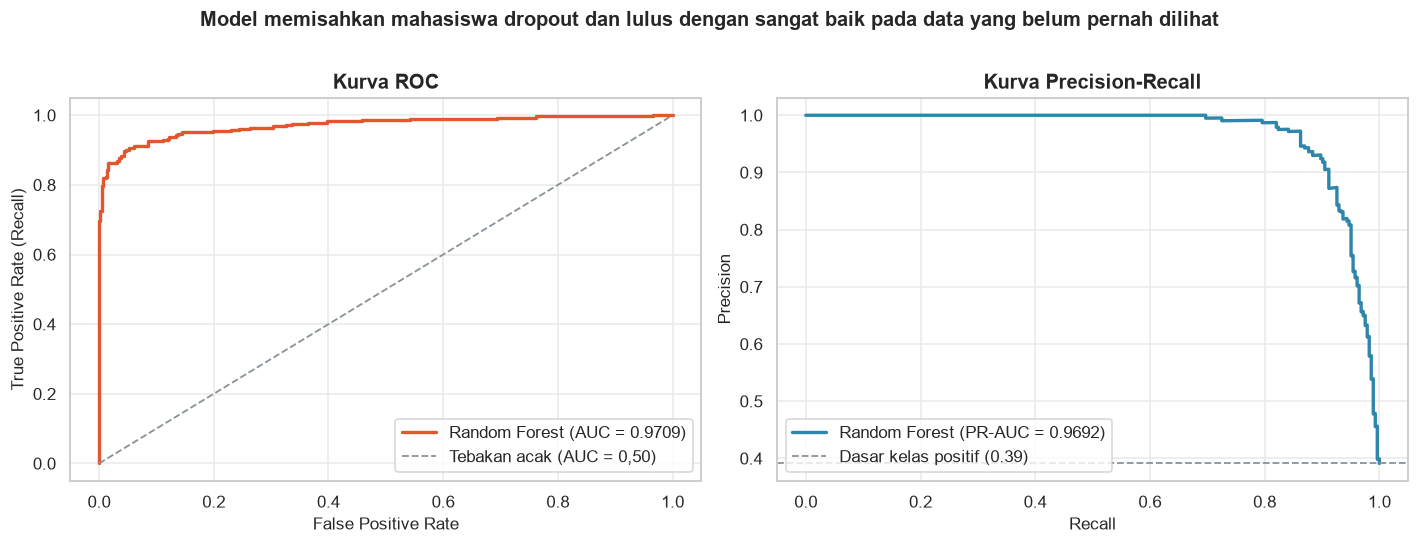

In [16]:
proba_uji = model_terbaik.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, proba_uji):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba_uji):.4f}")
print("\n=== Classification report pada ambang standar 0,50 ===")
print(classification_report(y_test, (proba_uji >= 0.5).astype(int),
                            target_names=["Graduate", "Dropout"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fpr, tpr, _ = roc_curve(y_test, proba_uji)
axes[0].plot(fpr, tpr, color=DROPOUT, lw=2.2,
             label=f"Random Forest (AUC = {roc_auc_score(y_test, proba_uji):.4f})")
axes[0].plot([0, 1], [0, 1], ls="--", color=GREY, lw=1.2, label="Tebakan acak (AUC = 0,50)")
axes[0].set_title("Kurva ROC"); axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)"); axes[0].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, proba_uji)
axes[1].plot(rec, prec, color=NEUTRAL, lw=2.2,
             label=f"Random Forest (PR-AUC = {average_precision_score(y_test, proba_uji):.4f})")
axes[1].axhline(y_test.mean(), ls="--", color=GREY, lw=1.2,
                label=f"Dasar kelas positif ({y_test.mean():.2f})")
axes[1].set_title("Kurva Precision-Recall"); axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision"); axes[1].legend(loc="lower left")

fig.suptitle("Model memisahkan mahasiswa dropout dan lulus dengan sangat baik pada data yang belum pernah dilihat",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(ASSETS / "07_kurva_evaluasi.png")
plt.show()

**Insight performa model.** Pada 726 mahasiswa data uji yang belum pernah dilihat model:
**ROC-AUC 0,9709** dan **PR-AUC 0,9692** (dibanding garis dasar kelas positif 0,39). Artinya,
bila diambil satu mahasiswa dropout dan satu mahasiswa lulus secara acak, model memberi skor
lebih tinggi kepada yang benar-benar dropout pada **97 dari 100 kasus**.

Pada ambang standar 0,50 model mencapai akurasi 0,9146 dengan precision 0,8750 dan recall
0,9120. Recall 0,9120 berarti **8,8% mahasiswa dropout masih lolos tanpa terdeteksi** —
25 orang dari 284. Untuk kasus retensi mahasiswa, angka tersebut masih dapat diperbaiki dengan
menyesuaikan ambang keputusan.

 Ambang  Precision  Recall     F1     F2  Akurasi  Ditandai
   0.20     0.6833  0.9648 0.8000 0.8913   0.8113       401
   0.25     0.7486  0.9542 0.8390 0.9045   0.8567       362
   0.30     0.7872  0.9507 0.8612 0.9128   0.8802       343
   0.35     0.8078  0.9472 0.8720 0.9156   0.8912       333
   0.40     0.8235  0.9366 0.8764 0.9116   0.8967       323
   0.45     0.8567  0.9261 0.8900 0.9113   0.9105       307
   0.50     0.8750  0.9120 0.8931 0.9043   0.9146       296
   0.55     0.9024  0.9120 0.9072 0.9100   0.9270       287
   0.60     0.9331  0.8838 0.9078 0.8932   0.9298       269
   0.65     0.9432  0.8768 0.9088 0.8893   0.9311       264
   0.70     0.9570  0.8627 0.9074 0.8800   0.9311       256
   0.75     0.9717  0.8451 0.9040 0.8677   0.9298       247
   0.80     0.9870  0.7993 0.8833 0.8309   0.9174       230

Ambang operasional terpilih (F2 maksimum): 0.35


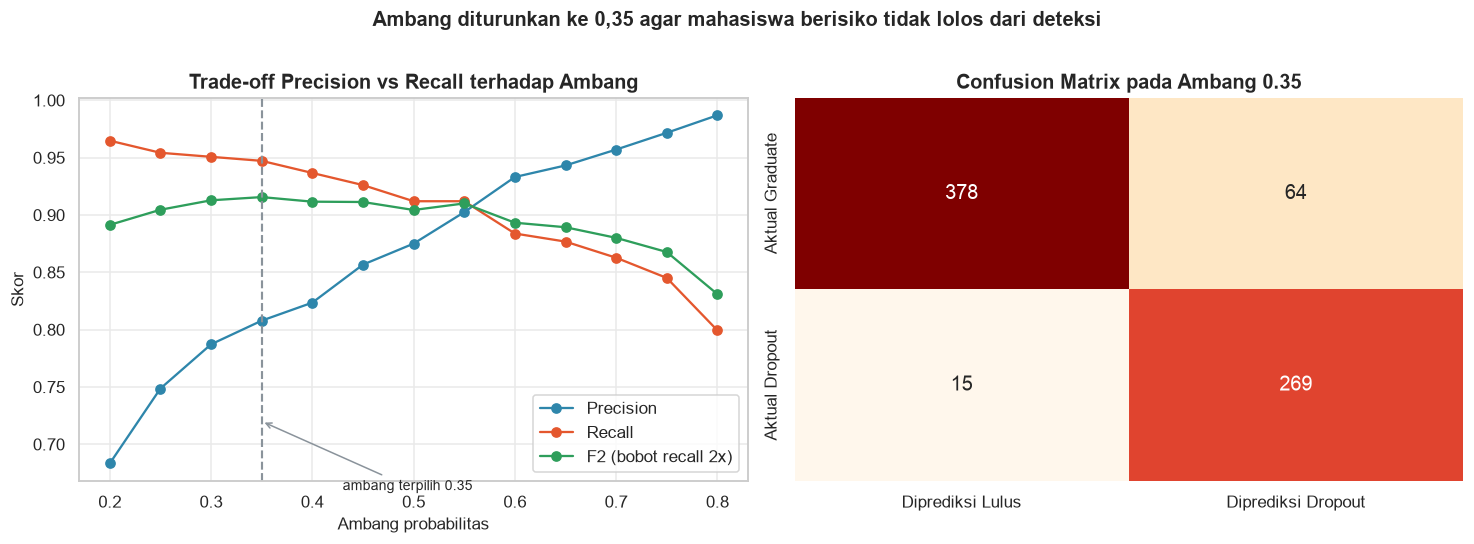


=== Classification report pada ambang operasional ===
              precision    recall  f1-score   support

    Graduate     0.9618    0.8552    0.9054       442
     Dropout     0.8078    0.9472    0.8720       284

    accuracy                         0.8912       726
   macro avg     0.8848    0.9012    0.8887       726
weighted avg     0.9016    0.8912    0.8923       726



In [17]:
ambang_uji = np.arange(0.20, 0.80, 0.05)
sweep = pd.DataFrame([{
    "Ambang": round(t, 2),
    "Precision": precision_score(y_test, (proba_uji >= t).astype(int)),
    "Recall": recall_score(y_test, (proba_uji >= t).astype(int)),
    "F1": f1_score(y_test, (proba_uji >= t).astype(int)),
    "F2": fbeta_score(y_test, (proba_uji >= t).astype(int), beta=2),
    "Akurasi": accuracy_score(y_test, (proba_uji >= t).astype(int)),
    "Ditandai": int((proba_uji >= t).sum()),
} for t in ambang_uji])

AMBANG = float(sweep.loc[sweep["F2"].idxmax(), "Ambang"])
print(sweep.round(4).to_string(index=False))
print(f"\nAmbang operasional terpilih (F2 maksimum): {AMBANG:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].plot(sweep["Ambang"], sweep["Precision"], marker="o", color=NEUTRAL, label="Precision")
axes[0].plot(sweep["Ambang"], sweep["Recall"], marker="o", color=DROPOUT, label="Recall")
axes[0].plot(sweep["Ambang"], sweep["F2"], marker="o", color=SAFE, label="F2 (bobot recall 2x)")
axes[0].axvline(AMBANG, ls="--", color=GREY, lw=1.4)
axes[0].annotate(f"ambang terpilih {AMBANG:.2f}", (AMBANG, 0.72), xytext=(AMBANG + 0.08, 0.66),
                 fontsize=9, arrowprops={"arrowstyle": "->", "color": GREY})
axes[0].set_title("Trade-off Precision vs Recall terhadap Ambang")
axes[0].set_xlabel("Ambang probabilitas"); axes[0].set_ylabel("Skor"); axes[0].legend()

cm = confusion_matrix(y_test, (proba_uji >= AMBANG).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap="OrRd", cbar=False, ax=axes[1],
            xticklabels=["Diprediksi Lulus", "Diprediksi Dropout"],
            yticklabels=["Aktual Graduate", "Aktual Dropout"], annot_kws={"fontsize": 13})
axes[1].set_title(f"Confusion Matrix pada Ambang {AMBANG:.2f}")

fig.suptitle("Ambang diturunkan ke 0,35 agar mahasiswa berisiko tidak lolos dari deteksi",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(ASSETS / "08_ambang_operasional.png")
plt.show()

print("\n=== Classification report pada ambang operasional ===")
print(classification_report(y_test, (proba_uji >= AMBANG).astype(int),
                            target_names=["Graduate", "Dropout"], digits=4))

**Insight pemilihan ambang — keputusan bisnis, bukan keputusan statistik.**

Dua jenis kesalahan tidak memiliki biaya yang sama:

| Kesalahan | Konsekuensi | Biaya |
|---|---|---|
| **False negative** — mahasiswa berisiko tidak terdeteksi | Mahasiswa dropout tanpa pernah mendapat bimbingan; institut kehilangan pendapatan sisa masa studi | **Tinggi** |
| **False positive** — mahasiswa aman ikut ditandai | Satu sesi konseling yang sebenarnya tidak diperlukan | **Rendah** |

Karena itu ambang dipilih dengan memaksimalkan **F2-score** (memberi bobot recall dua kali
lipat precision), dan hasilnya adalah **ambang 0,35**. Perbandingannya:

| Ambang | Precision | Recall | F2 | Dropout yang lolos |
|---|---|---|---|---|
| 0,50 (standar) | 0,8750 | 0,9120 | 0,9043 | 25 dari 284 |
| **0,35 (terpilih)** | **0,8078** | **0,9472** | **0,9156** | **15 dari 284** |

Menurunkan ambang menaikkan recall dari 91,2% ke **94,7%** — jumlah mahasiswa dropout yang lolos
**turun dari 25 menjadi 15 orang**. Ongkosnya: 333 mahasiswa ditandai (bukan 296), dengan
27 tambahan mahasiswa yang sebenarnya akan lulus ikut terpanggil konseling. Untuk unit bimbingan,
pertukaran itu jelas menguntungkan.

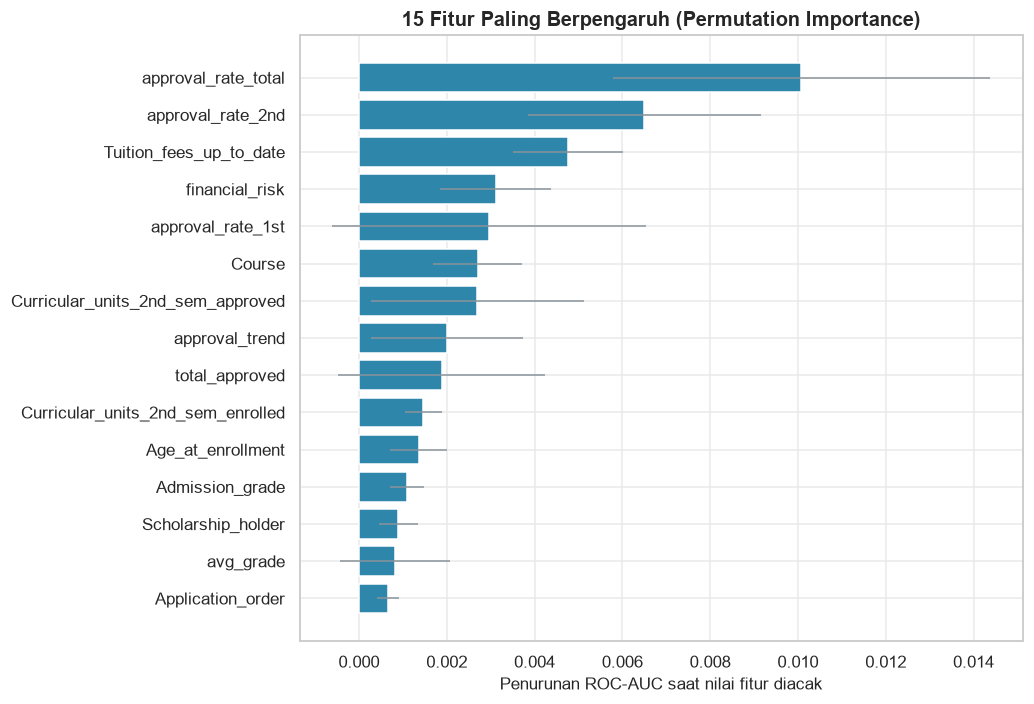

                            fitur  importance     std
              approval_rate_total     0.01008 0.00430
                approval_rate_2nd     0.00650 0.00266
          Tuition_fees_up_to_date     0.00477 0.00125
                   financial_risk     0.00311 0.00127
                approval_rate_1st     0.00296 0.00357
                           Course     0.00270 0.00101
Curricular_units_2nd_sem_approved     0.00270 0.00243
                   approval_trend     0.00201 0.00173
                   total_approved     0.00188 0.00235
Curricular_units_2nd_sem_enrolled     0.00147 0.00041


In [18]:
hasil_perm = permutation_importance(model_terbaik, X_test, y_test, n_repeats=15,
                                    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
importance = (pd.DataFrame({"fitur": X_test.columns,
                            "importance": hasil_perm.importances_mean,
                            "std": hasil_perm.importances_std})
              .sort_values("importance", ascending=False).reset_index(drop=True))

top15 = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.barh(top15["fitur"], top15["importance"], xerr=top15["std"],
        color=NEUTRAL, error_kw={"ecolor": GREY, "lw": 1})
ax.set_title("15 Fitur Paling Berpengaruh (Permutation Importance)")
ax.set_xlabel("Penurunan ROC-AUC saat nilai fitur diacak")
fig.tight_layout()
fig.savefig(ASSETS / "09_feature_importance.png")
plt.show()

print(importance.head(10).round(5).to_string(index=False))

**Insight faktor penentu dropout.** *Permutation importance* mengukur seberapa jauh ROC-AUC
turun ketika nilai satu fitur diacak — semakin besar penurunannya, semakin bergantung model
pada fitur tersebut. Sepuluh besarnya:

| # | Fitur | Penurunan ROC-AUC | Kelompok |
|---|---|---|---|
| 1 | `approval_rate_total` | 0,0101 | Akademik |
| 2 | `approval_rate_2nd` | 0,0065 | Akademik |
| 3 | `Tuition_fees_up_to_date` | 0,0048 | **Keuangan** |
| 4 | `financial_risk` | 0,0031 | **Keuangan** |
| 5 | `approval_rate_1st` | 0,0030 | Akademik |
| 6 | `Course` | 0,0027 | Program studi |
| 7 | `Curricular_units_2nd_sem_approved` | 0,0027 | Akademik |
| 8 | `approval_trend` | 0,0020 | Akademik |
| 9 | `total_approved` | 0,0019 | Akademik |
| 10 | `Curricular_units_2nd_sem_enrolled` | 0,0015 | Akademik |

Tiga kesimpulan:

1. **Enam dari sepuluh fitur teratas adalah fitur hasil rekayasa** (`approval_rate_*`,
   `approval_trend`, `financial_risk`, `total_approved`). Feature engineering memberi kontribusi
   nyata, bukan sekadar formalitas.
2. **Rasio kelulusan mata kuliah mendominasi**, dan `approval_trend` masuk sepuluh besar — model
   tidak hanya melihat posisi mahasiswa, tetapi juga **arah perubahannya**. Mahasiswa yang
   memburuk dari semester 1 ke semester 2 lebih berisiko daripada yang stabil di level sama.
3. **Dua fitur keuangan menempati posisi 3 dan 4.** Kondisi keuangan berdiri sendiri sebagai
   penyebab, bukan sekadar gejala performa akademik yang buruk.

ROC-AUC out-of-fold pada 3.630 mahasiswa berlabel: 0.9562
PR-AUC  out-of-fold                              : 0.9531

=== Kalibrasi band risiko ===
               Jumlah Mahasiswa  Dropout Aktual (%)
Rendah                     1773                 5.4
Sedang                      309                12.3
Tinggi                      283                39.6
Sangat Tinggi              1265                93.0


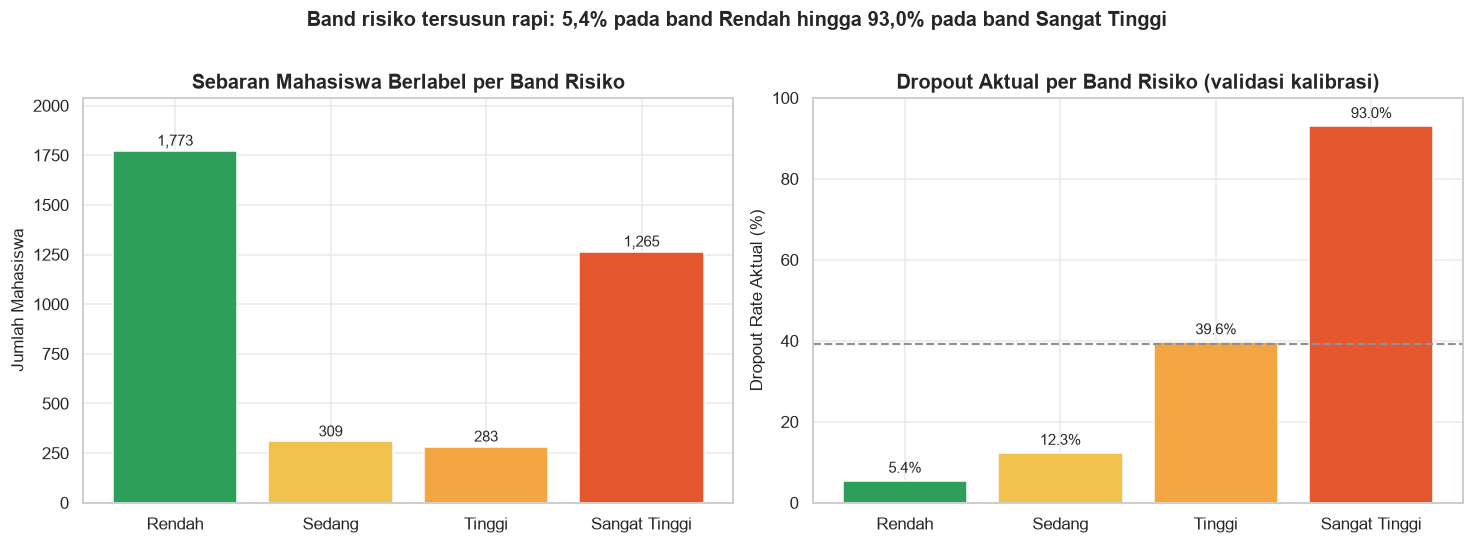

In [19]:
# Skor risiko out-of-fold: setiap mahasiswa dinilai oleh model yang tidak pernah melihat
# datanya, sehingga angka pada dashboard tidak terlalu optimistis (bebas bias in-sample).
risiko_oof = cross_val_predict(clone(model_terbaik), X, y, cv=cv,
                               method="predict_proba", n_jobs=-1)[:, 1]

print(f"ROC-AUC out-of-fold pada 3.630 mahasiswa berlabel: {roc_auc_score(y, risiko_oof):.4f}")
print(f"PR-AUC  out-of-fold                              : {average_precision_score(y, risiko_oof):.4f}")

band = pd.Series([pp.risk_band(v) for v in risiko_oof], index=X.index)
urut_band = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
kalibrasi = pd.DataFrame({
    "Jumlah Mahasiswa": band.value_counts().reindex(urut_band),
    "Dropout Aktual (%)": (y.groupby(band).mean() * 100).reindex(urut_band).round(1),
})
print("\n=== Kalibrasi band risiko ===")
print(kalibrasi.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
warna_band = ["#2E9E5B", "#F2C14E", "#F2A541", "#E4572E"]
axes[0].bar(urut_band, kalibrasi["Jumlah Mahasiswa"], color=warna_band)
for x, v in enumerate(kalibrasi["Jumlah Mahasiswa"]):
    axes[0].text(x, v + 25, f"{int(v):,}", ha="center", fontsize=10)
axes[0].set_title("Sebaran Mahasiswa Berlabel per Band Risiko")
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].set_ylim(0, kalibrasi["Jumlah Mahasiswa"].max() * 1.15)

axes[1].bar(urut_band, kalibrasi["Dropout Aktual (%)"], color=warna_band)
axes[1].axhline(BASELINE, ls="--", color=GREY, lw=1.4)
for x, v in enumerate(kalibrasi["Dropout Aktual (%)"]):
    axes[1].text(x, v + 2, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_title("Dropout Aktual per Band Risiko (validasi kalibrasi)")
axes[1].set_ylabel("Dropout Rate Aktual (%)"); axes[1].set_ylim(0, 100)

fig.suptitle("Band risiko tersusun rapi: 5,4% pada band Rendah hingga 93,0% pada band Sangat Tinggi",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(ASSETS / "10_band_risiko.png")
plt.show()

**Insight kalibrasi band risiko.** Skor probabilitas diringkas menjadi empat band agar dapat
dipakai staf akademik tanpa perlu menafsirkan angka desimal: **Rendah (<0,20), Sedang (0,20-0,35),
Tinggi (0,35-0,60), Sangat Tinggi (≥0,60)**. Batas 0,35 sengaja dibuat sama dengan ambang
operasional, sehingga band Tinggi dan Sangat Tinggi persis berisi mahasiswa yang ditandai model.

Pengujian silang membuktikan band ini **terkalibrasi dengan baik**:

| Band | Jumlah Mahasiswa | Dropout Aktual |
|---|---|---|
| Rendah | 1.773 | **5,4%** |
| Sedang | 309 | 12,3% |
| Tinggi | 283 | 39,6% |
| Sangat Tinggi | 1.265 | **93,0%** |

Kenaikannya monoton dan jaraknya sangat lebar — dari 5,4% ke 93,0%, atau **17 kali lipat**.
Band Sangat Tinggi praktis merupakan vonis: 93% mahasiswa di dalamnya benar-benar dropout.
ROC-AUC out-of-fold **0,9562** pada seluruh 3.630 mahasiswa berlabel juga mengonfirmasi bahwa
performa 0,9709 pada data uji bukan kebetulan pembagian data.

## Deployment

Tahap terakhir mengemas hasil analisis menjadi artefak yang dapat langsung dipakai:

1. **`model/dropout_model.joblib`** — pipeline lengkap (preprocessing + Random Forest terlatih)
   yang dilatih ulang pada **seluruh 3.630 mahasiswa berlabel**, dipakai aplikasi Streamlit.
2. **`model/model_metadata.json`** — kontrak model: daftar fitur, ambang operasional, metrik
   evaluasi, dan definisi band risiko, sehingga aplikasi tidak perlu menebak-nebak.
3. **`data/students_scored.csv`** — tabel analitik seluruh mahasiswa dengan label terbaca dan
   skor risiko; menjadi sumber data business dashboard Metabase.
4. **`data/enrolled_students.csv`** — 794 mahasiswa aktif dalam bentuk mentah, disimpan terpisah
   sebagai sasaran prediksi ke depan.
5. **`data/watchlist_enrolled.csv`** — daftar prioritas mahasiswa aktif hasil prediksi model,
   terurut dari risiko tertinggi. Inilah keluaran yang paling langsung dipakai institut.
6. **`data/feature_importance.csv`** — faktor penentu untuk panel dashboard.

In [20]:
# --- 1. Latih ulang model terpilih pada seluruh data berlabel ------------------------
model_final = clone(model_terbaik).fit(X, y)

# compress=3 menekan ukuran berkas dari ~40 MB menjadi ~10 MB tanpa mengubah model,
# penting agar aplikasi ringan saat di-deploy ke Streamlit Community Cloud.
joblib.dump(model_final, MODEL_DIR / "dropout_model.joblib", compress=3)

metadata = {
    "nama_model": nama_terbaik,
    "algoritma": type(model_final.named_steps["clf"]).__name__,
    "target": "1 = Dropout, 0 = Graduate (mahasiswa berstatus Enrolled tidak dilibatkan)",
    "jumlah_data_latih": int(len(X)),
    "proporsi_kelas_positif": round(float(y.mean()), 4),
    "jumlah_mahasiswa_enrolled_dipisah": int(len(enrolled)),
    "ambang_operasional": AMBANG,
    "alasan_ambang": "Memaksimalkan F2-score; biaya false negative jauh lebih tinggi "
                     "daripada false positive pada kasus retensi mahasiswa.",
    "fitur_kategorikal": pp.CATEGORICAL_FEATURES,
    "fitur_numerik": pp.NUMERIC_FEATURES,
    "kolom_input_mentah": pp.RAW_INPUT_COLUMNS,
    "hyperparameter": {k.replace("clf__", ""): (v if isinstance(v, (int, float, str, type(None))) else str(v))
                       for k, v in model_final.named_steps["clf"].get_params().items()
                       if k in {"n_estimators", "max_depth", "max_features",
                                "min_samples_leaf", "min_samples_split", "class_weight"}},
    "metrik_data_uji": {
        "roc_auc": round(float(roc_auc_score(y_test, proba_uji)), 4),
        "pr_auc": round(float(average_precision_score(y_test, proba_uji)), 4),
        "akurasi_ambang_operasional": round(float(accuracy_score(y_test, (proba_uji >= AMBANG).astype(int))), 4),
        "precision_ambang_operasional": round(float(precision_score(y_test, (proba_uji >= AMBANG).astype(int))), 4),
        "recall_ambang_operasional": round(float(recall_score(y_test, (proba_uji >= AMBANG).astype(int))), 4),
        "f2_ambang_operasional": round(float(fbeta_score(y_test, (proba_uji >= AMBANG).astype(int), beta=2)), 4),
    },
    "roc_auc_out_of_fold": round(float(roc_auc_score(y, risiko_oof)), 4),
    "band_risiko": [{"band": b, "batas_bawah": lo, "batas_atas": hi} for lo, hi, b in pp.RISK_BANDS],
    "versi_scikit_learn": sklearn.__version__,
}
(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Model disimpan  : {MODEL_DIR / 'dropout_model.joblib'} "
      f"({(MODEL_DIR / 'dropout_model.joblib').stat().st_size / 1024 / 1024:.1f} MB)")
print(f"Metadata        : {MODEL_DIR / 'model_metadata.json'}")
print(json.dumps(metadata["metrik_data_uji"], indent=2))

Model disimpan  : model/dropout_model.joblib (4.3 MB)
Metadata        : model/model_metadata.json
{
  "roc_auc": 0.9709,
  "pr_auc": 0.9692,
  "akurasi_ambang_operasional": 0.8912,
  "precision_ambang_operasional": 0.8078,
  "recall_ambang_operasional": 0.9472,
  "f2_ambang_operasional": 0.9156
}


In [21]:
# --- 2. Skoring ----------------------------------------------------------------------
# Mahasiswa berlabel  -> skor out-of-fold (model tidak pernah melihat datanya)
# Mahasiswa Enrolled  -> prediksi model final, murni sebagai perkiraan ke depan
risiko_enrolled = model_final.predict_proba(enrolled[pp.MODEL_FEATURES])[:, 1]

skor = pd.Series(np.nan, index=data.index)
skor.loc[X.index] = risiko_oof
skor.loc[enrolled.index] = risiko_enrolled

sumber = pd.Series("prediksi (mahasiswa aktif)", index=data.index)
sumber.loc[X.index] = "out-of-fold (data berlabel)"

print("=== Sebaran band risiko mahasiswa aktif (794 mahasiswa Enrolled) ===")
band_enrolled = pd.Series([pp.risk_band(v) for v in risiko_enrolled])
print(band_enrolled.value_counts().reindex(urut_band).to_string())
print(f"\nRata-rata skor risiko : {risiko_enrolled.mean() * 100:.1f}")
print(f"Di atas ambang {AMBANG:.2f}   : {int((risiko_enrolled >= AMBANG).sum()):,} mahasiswa")

=== Sebaran band risiko mahasiswa aktif (794 mahasiswa Enrolled) ===
Rendah           161
Sedang           101
Tinggi           170
Sangat Tinggi    362

Rata-rata skor risiko : 54.9
Di atas ambang 0.35   : 532 mahasiswa


**Insight prediksi mahasiswa aktif.** Dari **794 mahasiswa yang masih kuliah**, model
memperkirakan **532 mahasiswa (67%) berada di atas ambang intervensi**, terdiri atas **362 band
Sangat Tinggi** dan **170 band Tinggi**.

Satu catatan penting untuk pembacaan yang jujur: model dilatih pada dua kelompok dengan hasil
yang sudah pasti dan saling berlawanan (dropout versus lulus), sehingga **skornya cenderung
terpolarisasi** ketika diterapkan pada mahasiswa yang perjalanannya masih berlangsung. Angka
67% karena itu **tidak boleh dibaca sebagai "67% mahasiswa aktif pasti dropout"**, melainkan
sebagai *"67% mahasiswa aktif saat ini lebih menyerupai profil mahasiswa yang dulu dropout
daripada profil mahasiswa yang dulu lulus"*.

Cara pakai yang benar: **gunakan skor sebagai urutan prioritas**, bukan sebagai vonis. Unit
bimbingan memulai dari 362 mahasiswa band Sangat Tinggi — kelompok yang profil akademik dan
keuangannya paling menyerupai mahasiswa dropout terdahulu — lalu turun ke band Tinggi bila
kapasitas masih ada.

In [22]:
# --- 3. Tabel analitik untuk business dashboard --------------------------------------
scored = pp.add_readable_labels(pp.engineer_features(df)).copy()
scored.insert(0, "student_id", [f"JJI-{i:05d}" for i in range(1, len(scored) + 1)])
scored["dropout_probability"] = skor.round(4)
scored["risk_score"] = (skor * 100).round(1)
scored["risk_band"] = [pp.risk_band(v) for v in skor]
scored["sumber_skor"] = sumber
# is_dropout hanya diisi untuk mahasiswa yang status akhirnya sudah pasti; Enrolled -> kosong.
# Tipe Int64 (nullable integer) dipakai agar nilai tertulis "1"/"0"/kosong pada CSV,
# bukan "1.0"/"0.0" yang akan ditolak kolom SMALLINT di PostgreSQL.
scored["is_dropout"] = pd.Series(
    np.where(scored["Status"] == "Enrolled", np.nan,
             (scored["Status"] == pp.POSITIVE_CLASS).astype(float)),
    index=scored.index).astype("Int64")
scored["is_flagged"] = (skor >= AMBANG).astype(int)

kolom_dashboard = {
    "student_id": "student_id", "Status": "status", "is_dropout": "is_dropout",
    "risk_score": "risk_score", "risk_band": "risk_band", "is_flagged": "is_flagged",
    "sumber_skor": "sumber_skor",
    "program_studi": "program_studi", "jalur_masuk": "jalur_masuk",
    "jalur_masuk_detail": "jalur_masuk_detail", "waktu_kuliah": "waktu_kuliah",
    "jenis_kelamin": "jenis_kelamin", "status_pernikahan": "status_pernikahan",
    "kelompok_usia": "kelompok_usia", "Age_at_enrollment": "usia_saat_daftar",
    "band_nilai_masuk": "band_nilai_masuk", "Admission_grade": "nilai_masuk",
    "status_keuangan": "status_keuangan",
    "tuition_fees_up_to_date_label": "ukt_lunas", "debtor_label": "menunggak",
    "scholarship_holder_label": "penerima_beasiswa", "displaced_label": "perantau",
    "international_label": "mahasiswa_internasional",
    "band_kelulusan_sks": "band_kelulusan_sks", "band_nilai_semester": "band_nilai_semester",
    "approval_rate_total": "rasio_kelulusan", "avg_grade": "rata_rata_nilai",
    "approval_trend": "tren_kelulusan", "total_approved": "total_mk_lulus",
    "Curricular_units_1st_sem_approved": "mk_lulus_sem1",
    "Curricular_units_2nd_sem_approved": "mk_lulus_sem2",
    "Curricular_units_1st_sem_grade": "nilai_sem1",
    "Curricular_units_2nd_sem_grade": "nilai_sem2",
}
tabel_dashboard = scored[list(kolom_dashboard)].rename(columns=kolom_dashboard).round(4)
tabel_dashboard.to_csv(DATA_DIR / "students_scored.csv", index=False)

# Data mentah mahasiswa aktif, disimpan terpisah untuk kebutuhan prediksi berikutnya
df.loc[enrolled.index, pp.RAW_INPUT_COLUMNS].assign(
    student_id=tabel_dashboard.loc[enrolled.index, "student_id"]
).to_csv(DATA_DIR / "enrolled_students.csv", index=False)

importance.rename(columns={"std": "std_dev"}).round(6).to_csv(
    DATA_DIR / "feature_importance.csv", index=False)

watchlist = (tabel_dashboard[tabel_dashboard["status"] == "Enrolled"]
             .sort_values("risk_score", ascending=False)
             .loc[:, ["student_id", "program_studi", "jalur_masuk", "kelompok_usia",
                      "status_keuangan", "ukt_lunas", "menunggak", "penerima_beasiswa",
                      "rasio_kelulusan", "rata_rata_nilai", "tren_kelulusan",
                      "risk_score", "risk_band"]])
watchlist.to_csv(DATA_DIR / "watchlist_enrolled.csv", index=False)

print(f"students_scored.csv     : {tabel_dashboard.shape[0]:,} baris x {tabel_dashboard.shape[1]} kolom")
print(f"enrolled_students.csv   : {len(enrolled):,} mahasiswa aktif (data mentah)")
print(f"watchlist_enrolled.csv  : {len(watchlist):,} mahasiswa aktif + skor risiko")
print(f"feature_importance.csv  : {len(importance)} baris\n")
watchlist.head(10)

students_scored.csv     : 4,424 baris x 33 kolom
enrolled_students.csv   : 794 mahasiswa aktif (data mentah)
watchlist_enrolled.csv  : 794 mahasiswa aktif + skor risiko
feature_importance.csv  : 29 baris



,student_id,program_studi,jalur_masuk,kelompok_usia,status_keuangan,ukt_lunas,menunggak,penerima_beasiswa,rasio_kelulusan,rata_rata_nilai,tren_kelulusan,risk_score,risk_band
64,JJI-00065,Desain Komunikasi,Pindahan / Ganti Program,23-25,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.0000,0.0,0.0000,99.9,Sangat Tinggi
3720,JJI-03721,Agronomi,Pemegang Ijazah/Diploma Lain,17-19,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.0833,5.5,-0.1667,99.9,Sangat Tinggi
2239,JJI-02240,Keperawatan Hewan,Jalur Usia >23 Tahun,23-25,Bermasalah (menunggak & UKT tertunggak),Tidak,Ya,Tidak,0.0000,0.0,0.0000,99.9,Sangat Tinggi
3896,JJI-03897,Desain Komunikasi,Seleksi Reguler,20-22,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.0833,5.5,-0.1667,99.9,Sangat Tinggi
89,JJI-00090,Teknik Informatika,Pindahan / Ganti Program,17-19,Perlu perhatian (1 masalah),Ya,Ya,Tidak,0.2000,5.0,-0.4000,99.9,Sangat Tinggi
3925,JJI-03926,Manajemen,Pindahan / Ganti Program,23-25,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.1000,5.0,-0.2000,99.9,Sangat Tinggi
3077,JJI-03078,Teknik Informatika,Pindahan / Ganti Program,26-30,Bermasalah (menunggak & UKT tertunggak),Tidak,Ya,Tidak,0.0000,0.0,0.0000,99.9,Sangat Tinggi
2794,JJI-02795,Manajemen (kelas malam),Jalur Usia >23 Tahun,26-30,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.0000,0.0,0.0000,99.9,Sangat Tinggi
942,JJI-00943,Pekerjaan Sosial,Jalur Usia >23 Tahun,31-40,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.0000,0.0,0.0000,99.9,Sangat Tinggi
253,JJI-00254,Jurnalistik & Komunikasi,Seleksi Reguler,17-19,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.0833,5.5,-0.1667,99.8,Sangat Tinggi


In [23]:
# --- 4. Uji muat ulang: memastikan artefak benar-benar dapat dipakai aplikasi -------
model_dimuat = joblib.load(MODEL_DIR / "dropout_model.joblib")
meta_dimuat = json.loads((MODEL_DIR / "model_metadata.json").read_text(encoding="utf-8"))

contoh_mahasiswa = pd.DataFrame([{
    "Marital_status": 1, "Application_mode": 39, "Application_order": 1, "Course": 9119,
    "Daytime_evening_attendance": 1, "Previous_qualification_grade": 120.0,
    "Admission_grade": 118.0, "Displaced": 0, "Debtor": 1, "Tuition_fees_up_to_date": 0,
    "Gender": 1, "Scholarship_holder": 0, "Age_at_enrollment": 28, "International": 0,
    "Curricular_units_1st_sem_enrolled": 6, "Curricular_units_1st_sem_approved": 2,
    "Curricular_units_1st_sem_grade": 10.5, "Curricular_units_2nd_sem_enrolled": 6,
    "Curricular_units_2nd_sem_approved": 1, "Curricular_units_2nd_sem_grade": 8.0,
}])

fitur_contoh = pp.prepare_for_model(contoh_mahasiswa)
peluang = float(model_dimuat.predict_proba(fitur_contoh)[0, 1])

print("Contoh: mahasiswa Teknik Informatika, 28 tahun, menunggak pembayaran, "
      "hanya lulus 3 dari 12 mata kuliah")
print(f"   Probabilitas dropout : {peluang:.1%}")
print(f"   Band risiko          : {pp.risk_band(peluang)}")
print(f"   Ambang institut      : {meta_dimuat['ambang_operasional']:.0%} "
      f"-> {'PERLU INTERVENSI' if peluang >= meta_dimuat['ambang_operasional'] else 'aman'}")

Contoh: mahasiswa Teknik Informatika, 28 tahun, menunggak pembayaran, hanya lulus 3 dari 12 mata kuliah
   Probabilitas dropout : 99.9%
   Band risiko          : Sangat Tinggi
   Ambang institut      : 35% -> PERLU INTERVENSI


**Penjelasan tahapan.** Artefak diuji muat ulang dari berkas (bukan dari memori notebook)
lalu dipakai memprediksi satu mahasiswa contoh. Pipeline menerima **20 kolom mentah**,
menjalankan feature engineering yang sama seperti saat pelatihan, dan mengembalikan probabilitas
dropout. Uji ini memastikan tidak ada ketergantungan tersembunyi pada state notebook — dasar
yang membuat aplikasi Streamlit dan dashboard Metabase berjalan konsisten.

## Conclusion

**Dropout adalah masalah nyata di Jaya Jaya Institut: dari 3.630 mahasiswa yang perjalanan
studinya sudah selesai, 1.421 orang (39,15%) berhenti sebelum lulus.** Proyek ini membuktikan
bahwa mayoritas kasus tersebut dapat diprediksi jauh sebelum terjadi. Model Random Forest yang
dibangun mencapai **ROC-AUC 0,9709** pada data uji dan menangkap **94,7% mahasiswa dropout**
pada ambang operasional 0,35 — hanya dengan data yang **sudah dimiliki institut pada akhir tahun
pertama**, tanpa survei atau pengumpulan data baru.

**1. Apa penyebab utama dropout?** Ada dua akar masalah yang berdiri sendiri.

- **Kondisi keuangan.** Mahasiswa yang pembayarannya belum lunas dropout **94,03%** berbanding
  30,66% pada yang lunas — dari 486 mahasiswa yang menunggak, 457 berakhir dropout. Status
  *debtor* menghasilkan pola serupa (75,54% vs 34,47%), sementara beasiswa terbukti protektif
  (13,83% vs 48,37%). Dua fitur keuangan (`Tuition_fees_up_to_date` dan `financial_risk`) juga
  menempati **posisi ketiga dan keempat** pada permutation importance model.
- **Keterlibatan akademik tahun pertama.** Mahasiswa yang hanya lulus 1-50% mata kuliah dropout
  **99,03%** dan yang tidak lulus satu pun dropout **87,92%**, sementara yang lulus 81-100% mata
  kuliah hanya **8,69%**. Rasio kelulusan mata kuliah (`approval_rate_total`, `approval_rate_2nd`)
  menempati dua posisi teratas pada permutation importance, dan semester kedua lebih prediktif
  daripada semester pertama (korelasi -0,74 vs -0,67).

**2. Siapa yang paling rentan?** Profil risiko tinggi terbentuk konsisten di beberapa dimensi:
mahasiswa **berusia 26-30 tahun (dropout 70,25%)**, **laki-laki (56,12%)**, **kelas malam
(50,74%)**, **berstatus menikah (54,74%)**, masuk lewat **jalur usia di atas 23 tahun (65,51%)**
atau **pindahan/pemegang ijazah lain (± 48%)**, dan terdaftar pada program studi **Teknik
Informatika (86,79%)**, **Pengelolaan Kuda (65,00%)**, atau **Manajemen kelas malam (63,55%)**.
Sebaliknya, Keperawatan — program studi terbesar dengan 666 mahasiswa — hanya dropout 17,72%.
**Masalah dropout tidak merata**, sehingga intervensi paling efisien bila difokuskan pada
segmen-segmen tersebut.

**3. Faktor apa yang paling menentukan menurut model?** Urutan sepuluh besarnya:
`approval_rate_total`, `approval_rate_2nd`, `Tuition_fees_up_to_date`, `financial_risk`,
`approval_rate_1st`, `Course`, `Curricular_units_2nd_sem_approved`, `approval_trend`,
`total_approved`, dan `Curricular_units_2nd_sem_enrolled`. Enam di antaranya adalah fitur hasil
rekayasa. Kehadiran `approval_trend` berarti model tidak hanya melihat posisi mahasiswa, tetapi
juga **arah perubahannya**.

**4. Seberapa dapat dipercaya skornya?** Band risiko diuji dengan prediksi *out-of-fold*:
**Rendah 5,4% — Sedang 12,3% — Tinggi 39,6% — Sangat Tinggi 93,0%** dropout aktual. Kenaikannya
monoton dengan rentang 17 kali lipat, sehingga label band dapat langsung dipercaya sebagai
urutan prioritas kerja.

**5. Apa hasil konkretnya sekarang?** Model diterapkan pada **794 mahasiswa yang masih aktif
kuliah** — kelompok yang sengaja tidak dilibatkan dalam pelatihan. Hasilnya: **362 mahasiswa
masuk band Sangat Tinggi** dan 170 band Tinggi, total **532 mahasiswa berada di atas ambang
intervensi**. Skor ini dibaca sebagai **urutan prioritas**, bukan vonis, karena model dilatih
pada dua kelompok yang hasilnya sudah pasti. Daftar nama lengkap beserta urutannya tersedia di
`data/watchlist_enrolled.csv`, pada panel terakhir dashboard, dan pada halaman *Monitoring
Angkatan* aplikasi Streamlit.

### Rekomendasi Action Items

- **1. Jadikan tunggakan pembayaran sebagai alarm dropout, bukan sekadar urusan administrasi.**
  Terapkan aturan: mahasiswa yang pembayarannya lewat jatuh tempo **lebih dari 30 hari otomatis
  dirujuk ke unit bimbingan**, bukan hanya menerima surat tagihan. Dasarnya: 94,03% mahasiswa
  dalam kondisi ini berakhir dropout. Sediakan opsi cicilan, penundaan, atau beasiswa darurat —
  penerima beasiswa hanya dropout 13,83%, kurang dari sepertiga non-penerima, sehingga memperluas
  beasiswa ke mahasiswa berisiko tinggi berpotensi menekan dropout paling besar per rupiah yang
  dikeluarkan.

- **2. Pasang sistem peringatan dini berbasis mata kuliah pada minggu ke-6 setiap semester.**
  Mahasiswa yang lulus di bawah 50% mata kuliah dropout **99,03%**, dan lebih dari 1.000
  mahasiswa berada pada kondisi tersebut. Jangan menunggu nilai akhir semester: pantau kehadiran
  dan hasil evaluasi tengah semester, lalu wajibkan konseling akademik bagi mahasiswa dengan
  rasio kelulusan di bawah 50%. Prioritaskan pula mahasiswa dengan `approval_trend` negatif
  karena performa yang memburuk antarsemester termasuk sepuluh besar penentu model.

- **3. Kerjakan daftar prioritas 362 mahasiswa aktif band Sangat Tinggi pada semester berjalan.**
  Gunakan `data/watchlist_enrolled.csv` atau panel "Daftar Prioritas Intervensi" pada dashboard.
  Tetapkan satu dosen wali sebagai penanggung jawab per mahasiswa, dengan target kontak maksimal
  dua minggu dan pencatatan hasil intervensi. Pencatatan ini penting karena menjadi data
  pelatihan putaran berikutnya untuk mengukur **program bimbingan mana yang benar-benar bekerja**.

- **4. Bentuk program pendampingan khusus untuk mahasiswa non-tradisional.**
  Mahasiswa jalur usia di atas 23 tahun (dropout 65,51%), kelas malam (50,74%), dan yang sudah
  menikah (54,74%) memiliki pola risiko yang sama: **kuliah bersaing dengan pekerjaan dan
  tanggung jawab keluarga**. Solusinya bukan bimbingan akademik biasa, melainkan fleksibilitas —
  kelas daring/rekaman, batas SKS lebih rendah pada tahun pertama, dan orientasi manajemen waktu
  di awal semester.

- **5. Lakukan audit kurikulum pada tiga program studi dengan dropout tertinggi.**
  Teknik Informatika (86,79%), Pengelolaan Kuda (65,00%), dan Manajemen kelas malam (63,55%)
  memiliki dropout **lebih dari tiga kali lipat** Keperawatan (17,72%). Selisih sebesar itu tidak
  dapat dijelaskan oleh profil mahasiswa saja. Periksa beban mata kuliah tahun pertama, tingkat
  kelulusan per mata kuliah, dan kualitas pembimbingan akademik pada ketiga program studi
  tersebut, lalu pelajari apa yang membuat Keperawatan berhasil dan replikasikan.

**Cara mengukur keberhasilan.** Pantau tiga indikator pada dashboard setiap akhir semester:
(1) dropout rate keseluruhan dengan **target turun dari 39,15% menjadi di bawah 30% dalam dua
tahun**, (2) jumlah mahasiswa band Sangat Tinggi yang berhasil bertahan setelah diintervensi,
dan (3) dropout rate pada tiga program studi prioritas. Model perlu **dilatih ulang setiap akhir
tahun akademik** dengan data angkatan terbaru — termasuk mahasiswa `Enrolled` yang status
akhirnya sudah diketahui — agar tetap relevan.